In [1]:
import pandas as pd

# Lecture des fichiers (séparateur ; et guillemets)
t1 = pd.read_csv("2026-municipales-T1-bv.csv", sep=";", dtype=str, quotechar='"')
t2 = pd.read_csv("2026-municipales-T2-bv.csv", sep=";", dtype=str, quotechar='"')
def extract_toulouse(df, tour="T1", nuance="LFI"):
    """Extrait participation et score de la nuance par bureau de vote pour Toulouse."""
    
    mask = (df["Code département"] == "31") & (df["Code commune"] == "31555")
    toul = df[mask].copy()
    
    if toul.empty:
        mask = df["Libellé commune"].str.contains("Toulouse", case=False, na=False)
        toul = df[mask].copy()
    
    print(f"{tour} : {len(toul)} bureaux de vote trouvés pour Toulouse (nuance recherchée : {nuance})")
    
    toul["% Votants"] = toul["% Votants"].str.replace(",", ".").str.replace("%", "").astype(float)
    
    scores = []
    for _, row in toul.iterrows():
        score = None
        for i in range(1, 14):
            col_nuance = f"Nuance liste {i}"
            col_voix_pct = f"% Voix/exprimés {i}"
            if col_nuance in row.index and pd.notna(row[col_nuance]) and row[col_nuance].strip() == nuance:
                val = row[col_voix_pct]
                if pd.notna(val) and val != "":
                    score = float(str(val).replace(",", ".").replace("%", ""))
                break
        scores.append(score)
    
    toul[f"Score_{tour}"] = scores
    
    result = toul[["Code BV", "% Votants", f"Score_{tour}"]].copy()
    result = result.rename(columns={"% Votants": f"Participation_{tour}"})
    
    return result

# T1 : nuance LFI, T2 : nuance LDVG
res_t1 = extract_toulouse(t1, "T1", nuance="LFI")
res_t2 = extract_toulouse(t2, "T2", nuance="LDVG")

merged = pd.merge(res_t1, res_t2, on="Code BV", how="outer").sort_values("Code BV").reset_index(drop=True)

print(f"\n{len(merged)} bureaux de vote au total\n")
print(merged.to_string(index=False))

T1 : 285 bureaux de vote trouvés pour Toulouse (nuance recherchée : LFI)
T2 : 285 bureaux de vote trouvés pour Toulouse (nuance recherchée : LDVG)

285 bureaux de vote au total

Code BV  Participation_T1  Score_T1  Participation_T2  Score_T2
   0001             58.33     27.78             64.90     43.22
   0002             62.60     28.67             70.70     44.71
   0003             63.61     32.80             67.42     48.31
   0004             59.75     30.34             66.33     49.38
   0005             58.10     37.82             64.96     51.50
   0006             57.14     33.33             64.86     53.24
   0007             56.95     26.53             68.27     38.25
   0008             61.95     37.68             66.92     60.45
   0009             62.75     38.08             68.20     58.46
   0010             64.23     26.88             69.83     46.48
   0011             69.37     25.61             75.00     45.29
   0012             69.80     27.66             73.48 

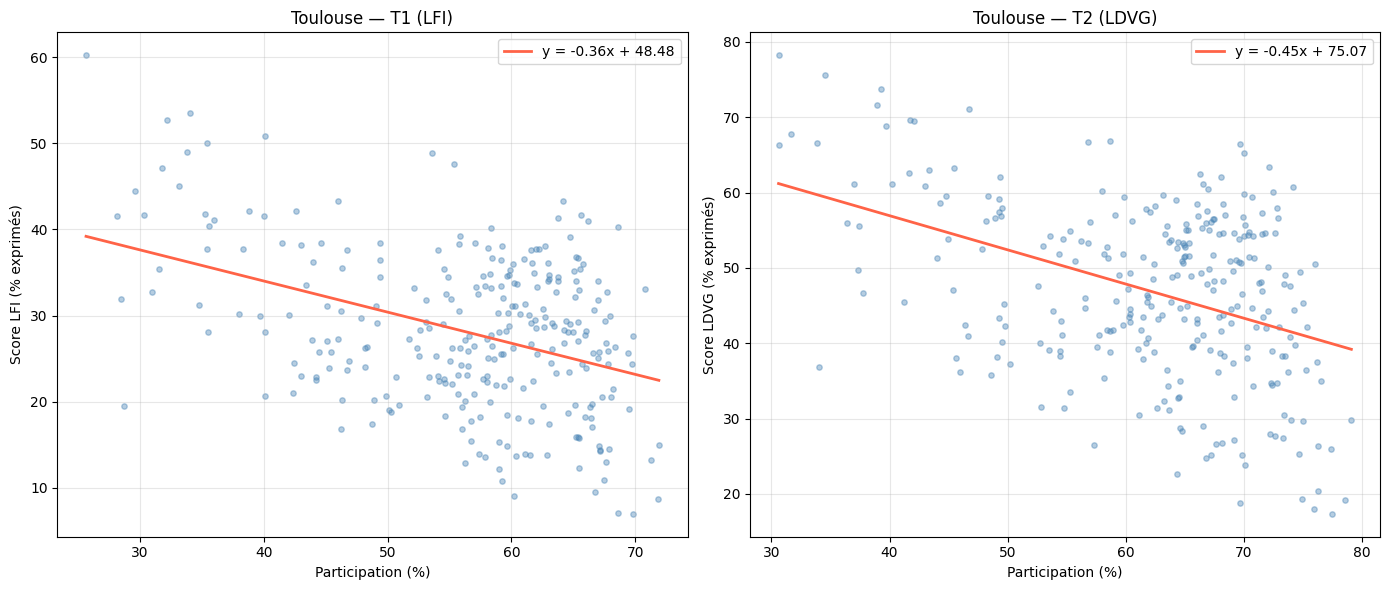

In [4]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, tour in zip(axes, ["T1", "T2"]):
    col_part = f"Participation_{tour}"
    col_score = f"Score_{tour}"
    
    # Retirer les NaN
    data = merged[[col_part, col_score]].dropna()
    data = data[data[col_part] >= 25]
    x = data[col_part].values
    y = data[col_score].values
    
    ax.scatter(x, y, alpha=0.4, s=15, color="steelblue")
    
    # Régression linéaire
    if len(x) > 1:
        coeffs = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = np.polyval(coeffs, x_line)
        ax.plot(x_line, y_line, color="tomato", linewidth=2,
                label=f"y = {coeffs[0]:.2f}x + {coeffs[1]:.2f}")
        ax.legend()
    
    nuance = "LFI" if tour == "T1" else "LDVG"
    ax.set_title(f"Toulouse — {tour} ({nuance})")
    ax.set_xlabel("Participation (%)")
    ax.set_ylabel(f"Score {nuance} (% exprimés)")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

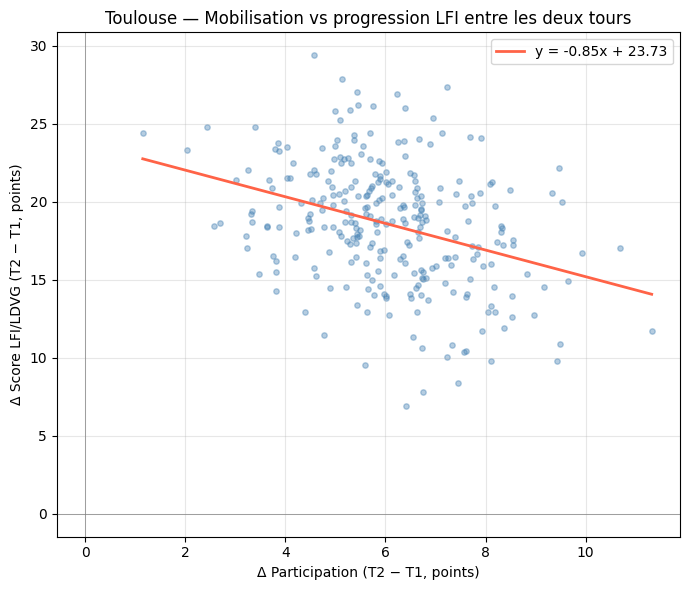

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))

temp = merged.dropna(subset=["Participation_T1", "Participation_T2", "Score_T1", "Score_T2"])
temp = temp[(temp["Participation_T1"] >= 25) & (temp["Participation_T2"] >= 25)]

x = (temp["Participation_T2"] - temp["Participation_T1"]).values
y = (temp["Score_T2"] - temp["Score_T1"]).values

ax.scatter(x, y, alpha=0.4, s=15, color="steelblue")

if len(x) > 1:
    coeffs = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = np.polyval(coeffs, x_line)
    ax.plot(x_line, y_line, color="tomato", linewidth=2,
            label=f"y = {coeffs[0]:.2f}x + {coeffs[1]:.2f}")
    ax.legend()

ax.axhline(0, color="grey", linewidth=0.5)
ax.axvline(0, color="grey", linewidth=0.5)
ax.set_xlabel("Δ Participation (T2 − T1, points)")
ax.set_ylabel("Δ Score LFI/LDVG (T2 − T1, points)")
ax.set_title("Toulouse — Mobilisation vs progression LFI entre les deux tours")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [31]:
def analyse_ville(t1, t2, ville, code_dept, code_commune, labels_t1, labels_t2, xaxis="Participation", yaxis="Score cumulé", part_min=0):
    """
    Analyse complète d'une ville avec somme des scores de plusieurs listes.
    
    Paramètres :
        t1, t2 : DataFrames des résultats T1 et T2
        ville : nom de la ville (pour les titres)
        code_dept : code département
        code_commune : code commune INSEE
        labels_t1 : liste de libellés abrégés de liste au T1
        labels_t2 : liste de libellés abrégés de liste au T2
        part_min : participation minimale (défaut 25%)
    """
    
    def extract(df, tour, labels):
        mask = (df["Code département"] == code_dept) & (df["Code commune"] == code_commune)
        toul = df[mask].copy()
        if toul.empty:
            mask = df["Libellé commune"].str.contains(ville, case=False, na=False)
            toul = df[mask].copy()
        
        print(f"{tour} : {len(toul)} bureaux de vote pour {ville}")
        print(f"  Libellés recherchés : {labels}")
        
        toul["% Votants"] = toul["% Votants"].str.replace(",", ".").str.replace("%", "").astype(float)
        
        labels_upper = [l.upper().strip() for l in labels]
        
        scores = []
        for _, row in toul.iterrows():
            total = 0.0
            found = []
            for i in range(1, 14):
                col_label = f"Libellé abrégé de liste {i}"
                col_voix_pct = f"% Voix/exprimés {i}"
                if col_label in row.index and pd.notna(row[col_label]):
                    label = str(row[col_label]).upper().strip()
                    if label in labels_upper:
                        val = row[col_voix_pct]
                        if pd.notna(val) and val != "":
                            total += float(str(val).replace(",", ".").replace("%", ""))
                            found.append(label)
            scores.append(total if found else None)
        
        toul[f"Score_{tour}"] = scores
        n_found = sum(1 for s in scores if s is not None)
        print(f"  Score trouvé dans {n_found}/{len(toul)} bureaux")
        
        result = toul[["Code BV", "% Votants", f"Score_{tour}"]].copy()
        result = result.rename(columns={"% Votants": f"Participation_{tour}"})
        return result
    
    res_t1 = extract(t1, "T1", labels_t1)
    res_t2 = extract(t2, "T2", labels_t2)
    merged = pd.merge(res_t1, res_t2, on="Code BV", how="outer").sort_values("Code BV").reset_index(drop=True)
    
    # --- Scatter deltas ---
    fig, ax = plt.subplots(figsize=(7, 6))
    temp = merged.dropna(subset=["Participation_T1", "Participation_T2", "Score_T1", "Score_T2"])
    temp = temp[(temp["Participation_T1"] >= part_min) & (temp["Participation_T2"] >= part_min)]
    x = (temp["Participation_T2"] - temp["Participation_T1"]).values
    y = (temp["Score_T2"] - temp["Score_T1"]).values
    
    ax.scatter(x, y, alpha=0.7, s=15, color="black", linewidths=0)
    if len(x) > 1:
        coeffs = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, np.polyval(coeffs, x_line), color="tomato", linewidth=2,
                label=f"y = {coeffs[0]:.2f}x + {coeffs[1]:.2f}")
        ax.legend()
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.axvline(0, color="grey", linewidth=0.5)
    ax.set_title(f"{ville} — Δ Participation vs Δ Score cumulé")
    ax.set_xlabel(f"{xaxis} (T2 − T1, points)")
    ax.set_ylabel(f"{yaxis} (T2 − T1, points)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return merged

T1 : 285 bureaux de vote pour Toulouse
  Libellés recherchés : ['Vivre mieux La gauche unie, écologiste, citoyenne et solidaire', 'Demain Toulouse à gauche et écologiste']
  Score trouvé dans 285/285 bureaux
T2 : 285 bureaux de vote pour Toulouse
  Libellés recherchés : ['Demain Toulouse La Gauche Unie']
  Score trouvé dans 285/285 bureaux


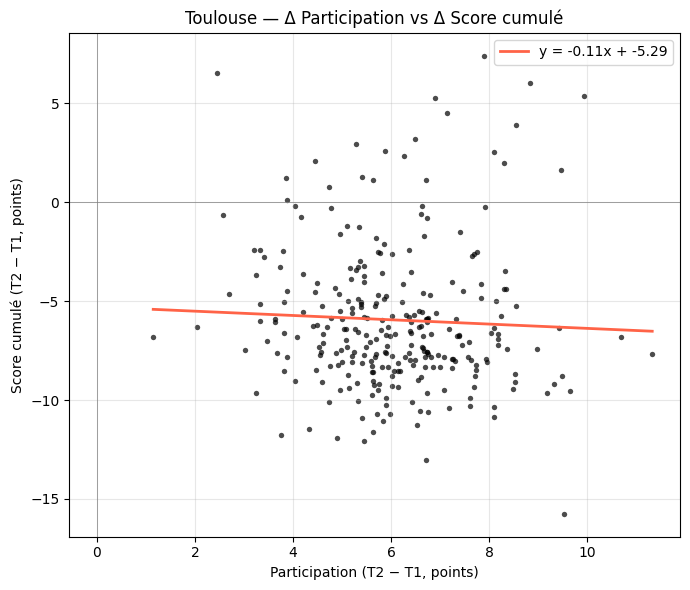

T1 : 285 bureaux de vote pour Toulouse
  Libellés recherchés : ["Avec Jean-Luc MOUDENC, Protégeons l'Avenir de Toulouse"]
  Score trouvé dans 285/285 bureaux
T2 : 285 bureaux de vote pour Toulouse
  Libellés recherchés : ["Avec Jean-Luc MOUDENC, Protégeons l'Avenir de Toulouse"]
  Score trouvé dans 285/285 bureaux


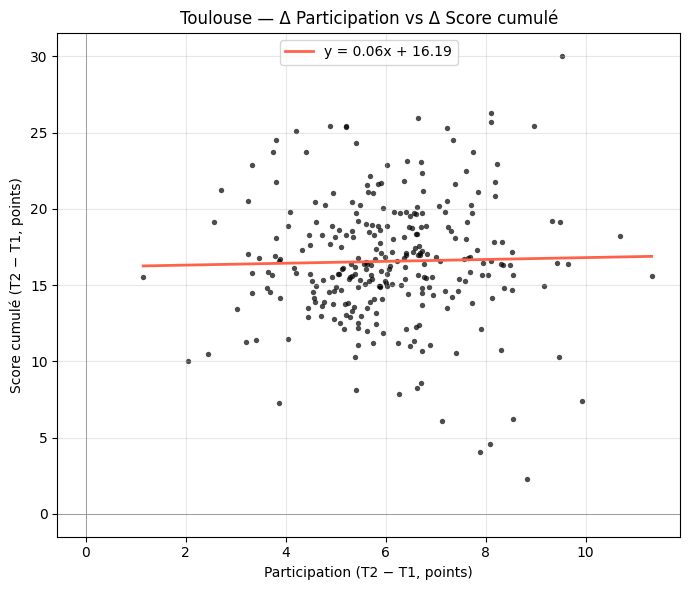

In [18]:
# Toulouse
df_toulouse = analyse_ville(t1, t2, "Toulouse", "31", "31555", ["Vivre mieux La gauche unie, écologiste, citoyenne et solidaire","Demain Toulouse à gauche et écologiste"], ["Demain Toulouse La Gauche Unie"])

# Toulouse
df_toulouse = analyse_ville(t1, t2, "Toulouse", "31", "31555", ["Avec Jean-Luc MOUDENC, Protégeons l'Avenir de Toulouse"], ["Avec Jean-Luc MOUDENC, Protégeons l'Avenir de Toulouse"])



T1 : 86 bureaux de vote pour Limoges
  Libellés recherchés : ['POUR LIMOGES THIERRY MIGUEL', 'Limoges Front Populaire - Union de la gauche sociale et écologiste']
  Score trouvé dans 86/86 bureaux
T2 : 86 bureaux de vote pour Limoges
  Libellés recherchés : ['Pour Limoges : Front Populaire - Union de la gauche sociale et écologiste']
  Score trouvé dans 86/86 bureaux


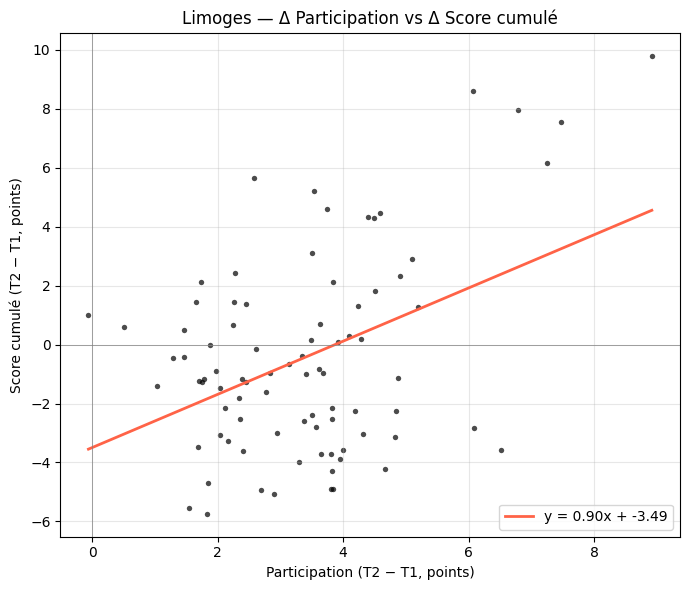

T1 : 86 bureaux de vote pour Limoges
  Libellés recherchés : ['LIMOGES EN GRAND']
  Score trouvé dans 86/86 bureaux
T2 : 86 bureaux de vote pour Limoges
  Libellés recherchés : ['LIMOGES EN GRAND']
  Score trouvé dans 86/86 bureaux


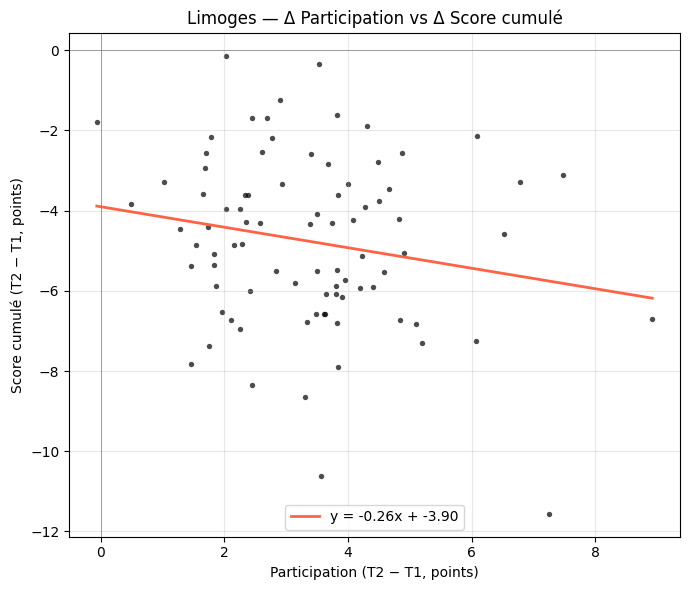

In [19]:

# Limoges
df_limoges = analyse_ville(t1, t2, "Limoges", "87", "87085", ["POUR LIMOGES THIERRY MIGUEL", "Limoges Front Populaire - Union de la gauche sociale et écologiste"] , ["Pour Limoges : Front Populaire - Union de la gauche sociale et écologiste"])


# Limoges
df_limoges = analyse_ville(t1, t2, "Limoges", "87", "87085", ["LIMOGES EN GRAND"] , ["LIMOGES EN GRAND"])

T1 : 497 bureaux de vote pour Marseille
  Libellés recherchés : ['MARSEILLE EN ORDRE']
  Score trouvé dans 497/497 bureaux
T2 : 497 bureaux de vote pour Marseille
  Libellés recherchés : ['MARSEILLE EN ORDRE']
  Score trouvé dans 497/497 bureaux


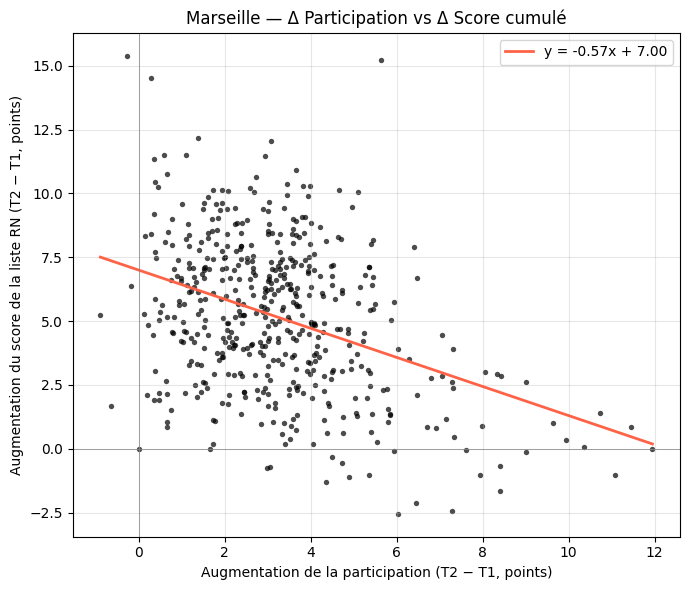

T1 : 497 bureaux de vote pour Marseille
  Libellés recherchés : ['POUR MARSEILLE, LA GAUCHE RASSEMBLES']
  Score trouvé dans 497/497 bureaux
T2 : 497 bureaux de vote pour Marseille
  Libellés recherchés : ['POUR MARSEILLE, LA GAUCHE RASSEMBLES']
  Score trouvé dans 497/497 bureaux


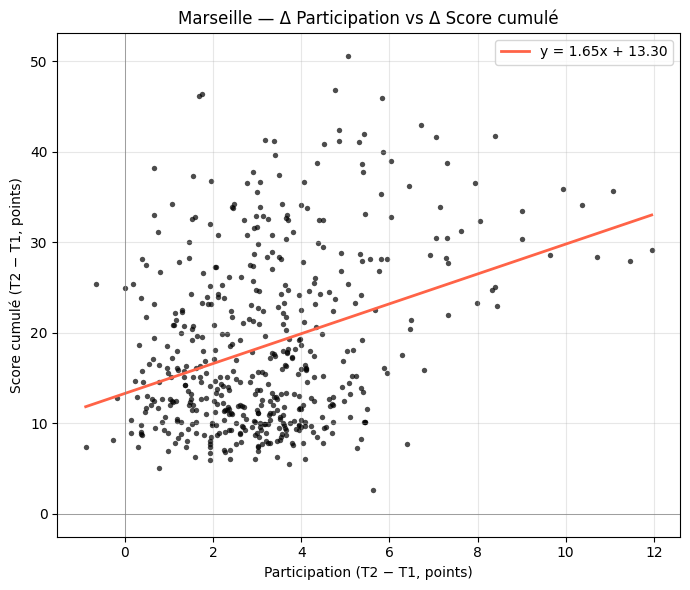

In [35]:

# Marseille
df_marseille = analyse_ville(t1, t2, "Marseille", "13", "13055", ["MARSEILLE EN ORDRE"], ["MARSEILLE EN ORDRE"], "Augmentation de la participation", "Augmentation du score de la liste RN")


# Marseille
df_marseille = analyse_ville(t1, t2, "Marseille", "13", "13055", ["POUR MARSEILLE, LA GAUCHE RASSEMBLES"], ["POUR MARSEILLE, LA GAUCHE RASSEMBLES"])

T1 : 128 bureaux de vote pour Toulon
  Libellés recherchés : ['UN AVENIR POUR TOULON']
  Score trouvé dans 128/128 bureaux
T2 : 128 bureaux de vote pour Toulon
  Libellés recherchés : ['UN AVENIR POUR TOULON']
  Score trouvé dans 128/128 bureaux


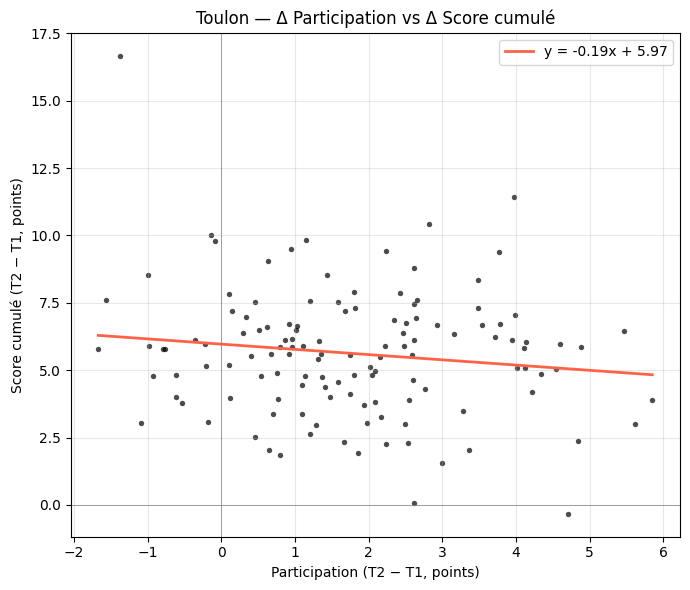

In [33]:

# Toulon
df_toulon = analyse_ville(t1, t2, "Toulon", "83", "83137", ["UN AVENIR POUR TOULON"], ["UN AVENIR POUR TOULON"])



T1 : 341 bureaux de vote pour Lyon
  Libellés recherchés : ['Faire Mieux Pour Lyon - La France Insoumise', "POUR VIVRE LYON, L'UNION DE LA GAUCHE ET DES ECOLOGISTES AVEC GREGORY DOUCET"]
  Score trouvé dans 314/341 bureaux
T2 : 314 bureaux de vote pour Lyon
  Libellés recherchés : ["POUR VIVRE LYON, L'UNION DE LA GAUCHE ET DES ECOLOGISTES AVEC GREGORY DOUCET"]
  Score trouvé dans 314/314 bureaux


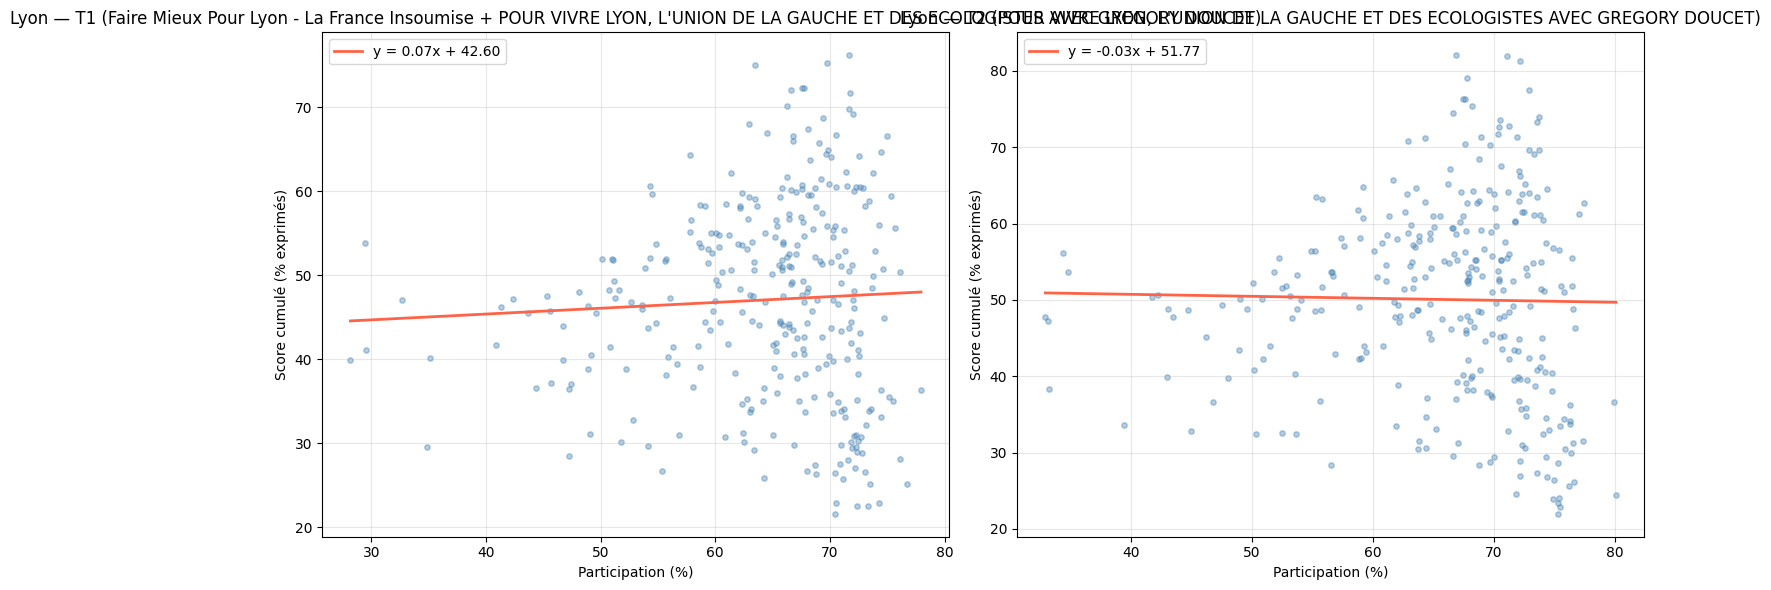

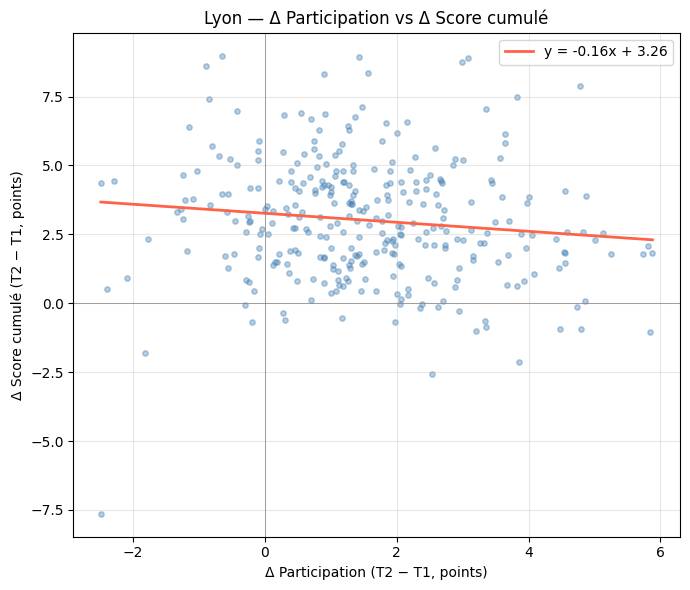

T1 : 341 bureaux de vote pour Lyon
  Libellés recherchés : ['Coeur Lyonnais']
  Score trouvé dans 314/341 bureaux
T2 : 314 bureaux de vote pour Lyon
  Libellés recherchés : ['Coeur Lyonnais']
  Score trouvé dans 314/314 bureaux


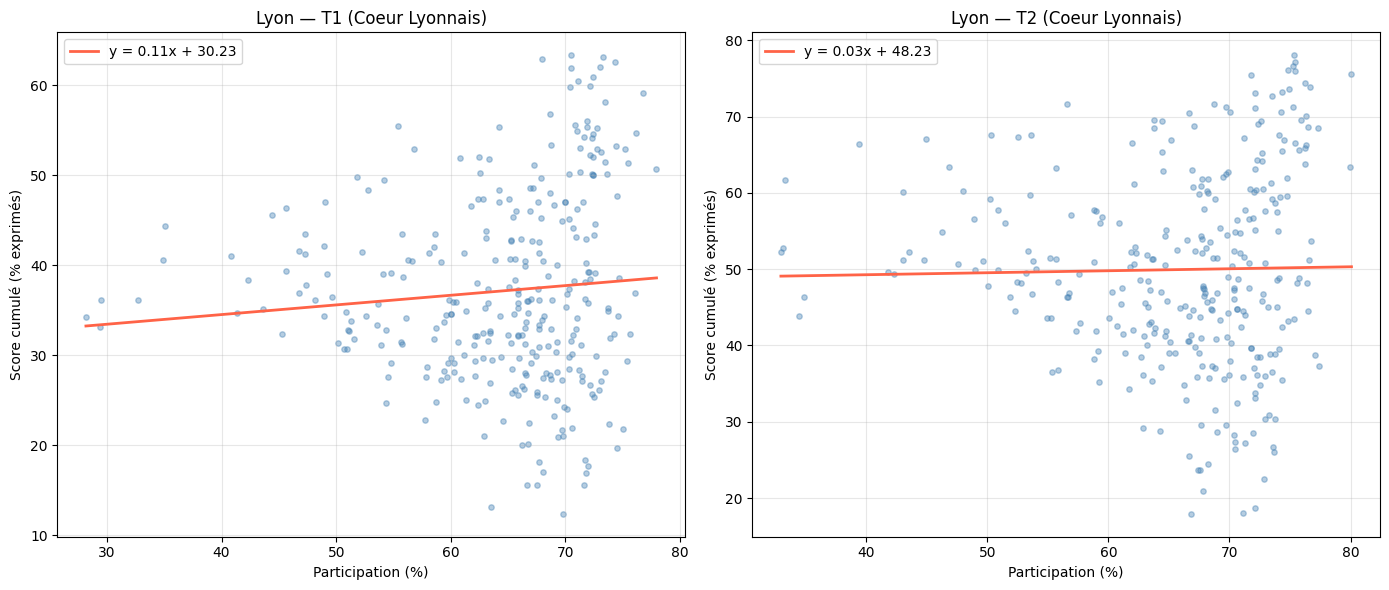

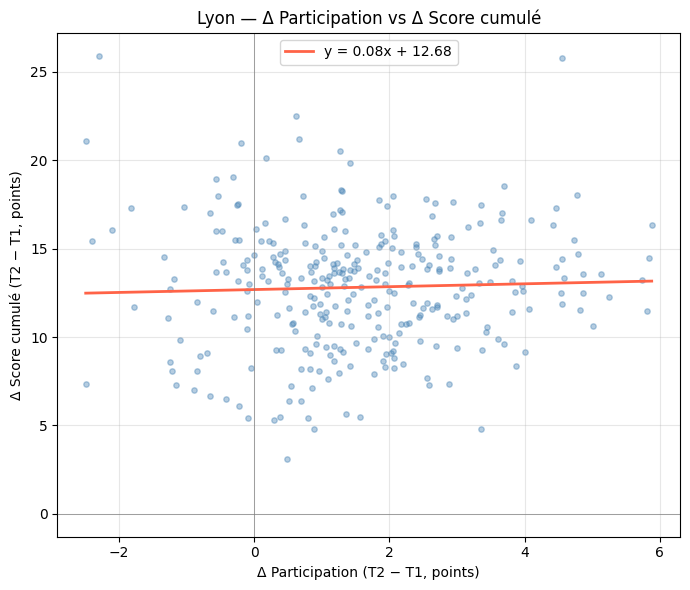

In [31]:

df_lyon = analyse_ville(t1, t2, "Lyon", "69", "69388", ["Faire Mieux Pour Lyon - La France Insoumise", "POUR VIVRE LYON, L'UNION DE LA GAUCHE ET DES ECOLOGISTES AVEC GREGORY DOUCET"], ["POUR VIVRE LYON, L'UNION DE LA GAUCHE ET DES ECOLOGISTES AVEC GREGORY DOUCET"])


df_lyon = analyse_ville(t1, t2, "Lyon", "69", "69388", ["Coeur Lyonnais"], ["Coeur Lyonnais"])

T1 : 128 bureaux de vote pour Toulon
  Libellés recherchés : ['UN AVENIR POUR TOULON']
  Score trouvé dans 128/128 bureaux
T2 : 128 bureaux de vote pour Toulon
  Libellés recherchés : ['UN AVENIR POUR TOULON']
  Score trouvé dans 128/128 bureaux


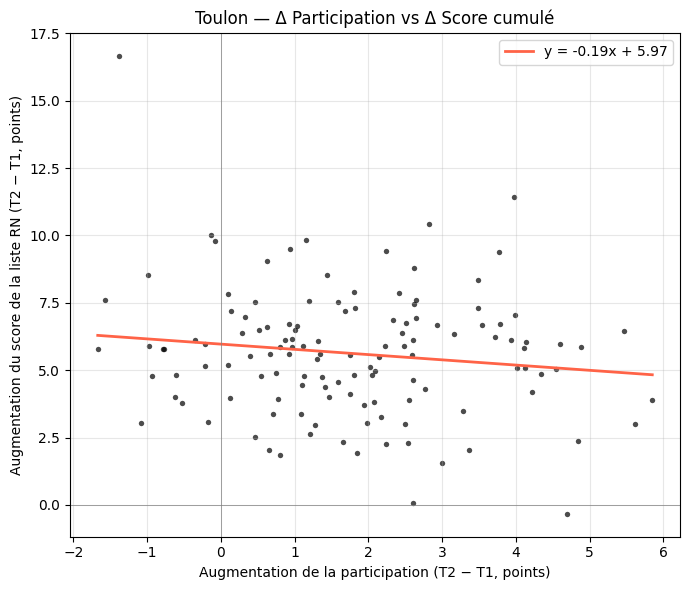

T1 : 86 bureaux de vote pour Nîmes
  Libellés recherchés : ["FIERS D'ÊTRE NÎMOIS !"]
  Score trouvé dans 86/86 bureaux
T2 : 86 bureaux de vote pour Nîmes
  Libellés recherchés : ["FIERS D'ÊTRE NÎMOIS !"]
  Score trouvé dans 86/86 bureaux


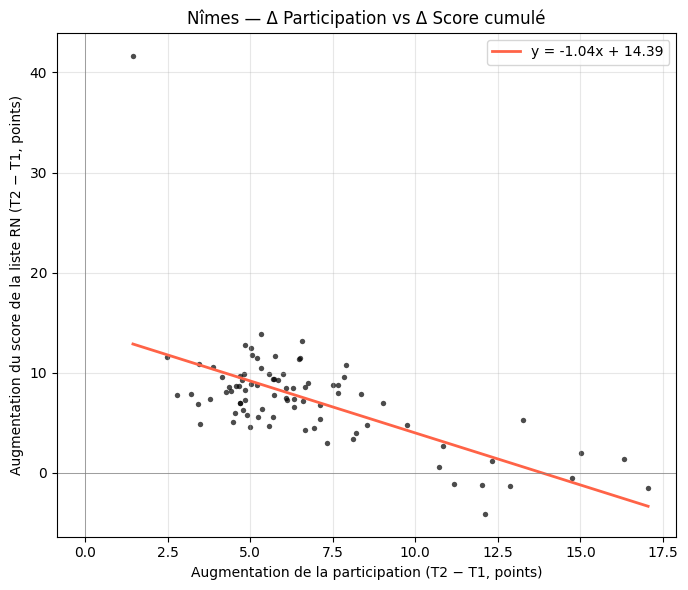

In [51]:

# Marseille
_ = analyse_ville(t1, t2, "Toulon", "83", "83137", ["UN AVENIR POUR TOULON"], ["UN AVENIR POUR TOULON"], "Augmentation de la participation", "Augmentation du score de la liste RN")
# Marseille
df_marseille = analyse_ville(t1, t2, "Nîmes", "30", "30189", ["FIERS D'ÊTRE NÎMOIS !"], ["FIERS D'ÊTRE NÎMOIS !"], "Augmentation de la participation", "Augmentation du score de la liste RN")

T1 : 256 bureaux de vote pour Nice
  Libellés recherchés : ['LE MEILLEUR EST A VENIR AVEC ERIC CIOTTI']
  Score trouvé dans 256/256 bureaux
T2 : 256 bureaux de vote pour Nice
  Libellés recherchés : ['LE MEILLEUR EST A VENIR AVEC ERIC CIOTTI']
  Score trouvé dans 256/256 bureaux


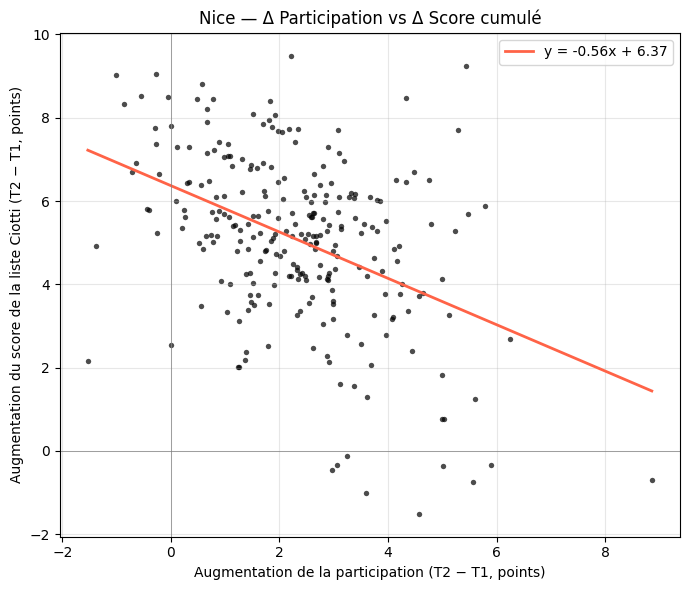

In [38]:

# Nice
df_nice = analyse_ville(t1, t2, "Nice", "06", "06088", ["LE MEILLEUR EST A VENIR AVEC ERIC CIOTTI"], ["LE MEILLEUR EST A VENIR AVEC ERIC CIOTTI"], "Augmentation de la participation", "Augmentation du score de la liste Ciotti")

T1 : 128 bureaux de vote pour Lille
  Libellés recherchés : ['LILLE INSOUMISE, ÉCOLOGISTE ET POPULAIRE']
  Score trouvé dans 128/128 bureaux
T2 : 128 bureaux de vote pour Lille
  Libellés recherchés : ['LILLE INSOUMISE, ÉCOLOGISTE ET POPULAIRE']
  Score trouvé dans 128/128 bureaux


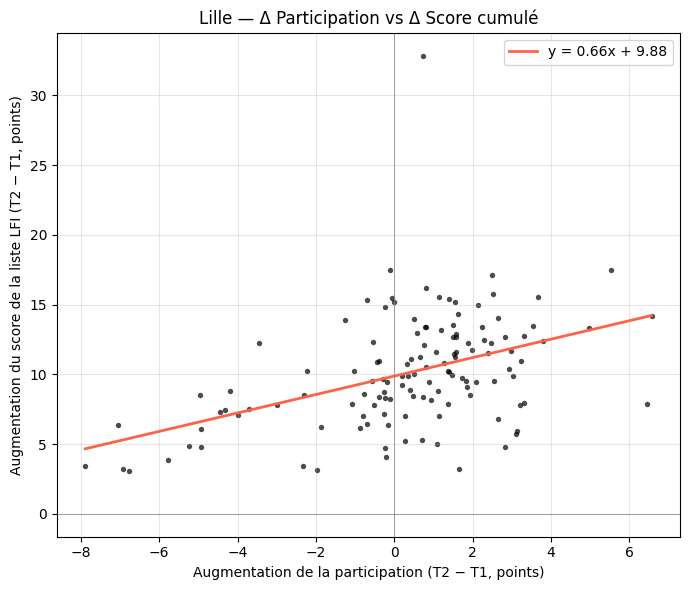

T1 : 208 bureaux de vote pour Nantes
  Libellés recherchés : ['La gauche unie pour Nantes', 'Nouvelle Nantes', 'Nantes Populaire']
  Score trouvé dans 208/208 bureaux
T2 : 208 bureaux de vote pour Nantes
  Libellés recherchés : ['La gauche unie pour Nantes']
  Score trouvé dans 208/208 bureaux


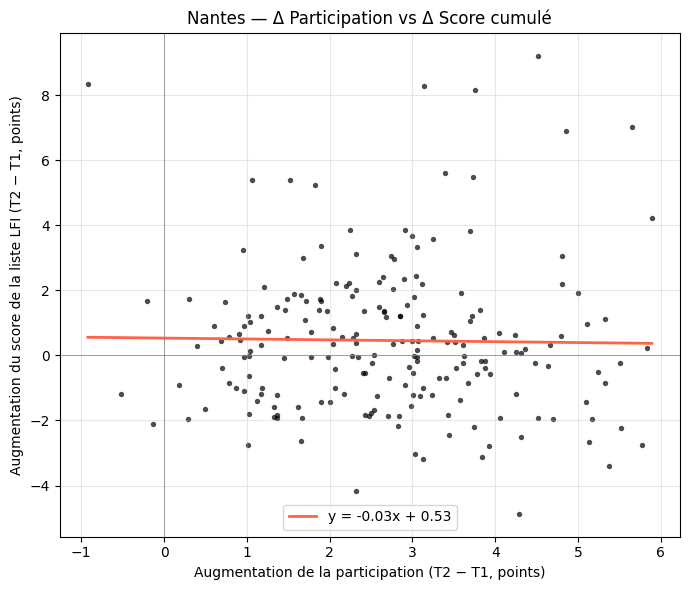

T1 : 139 bureaux de vote pour Montpellier
  Libellés recherchés : ['FAIRE MIEUX POUR MONTPELLIER']
  Score trouvé dans 139/139 bureaux
T2 : 139 bureaux de vote pour Montpellier
  Libellés recherchés : ['FAIRE MIEUX POUR MONTPELLIER']
  Score trouvé dans 139/139 bureaux


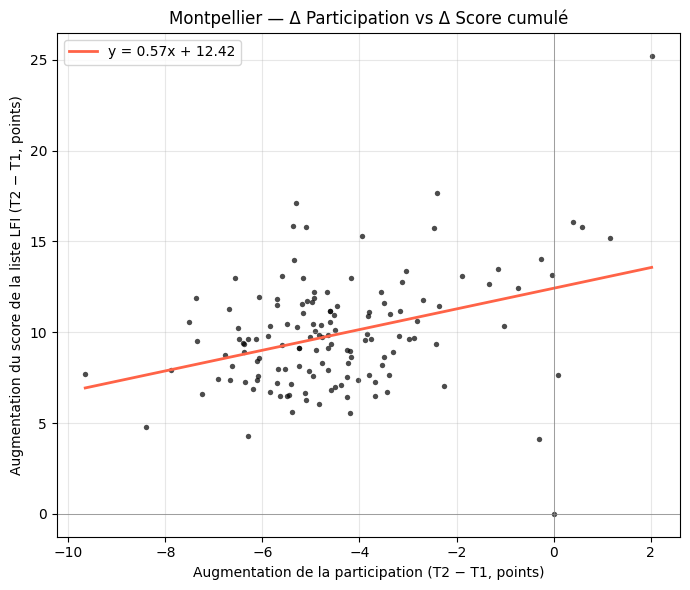

T1 : 139 bureaux de vote pour Montpellier
  Libellés recherchés : ['DEMAIN MONTPELLIER']
  Score trouvé dans 139/139 bureaux
T2 : 139 bureaux de vote pour Montpellier
  Libellés recherchés : ['DEMAIN MONTPELLIER']
  Score trouvé dans 139/139 bureaux


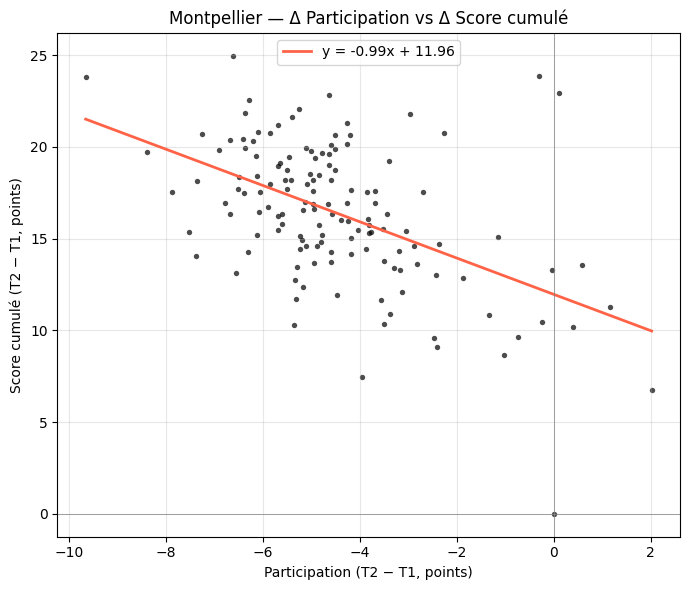

T1 : 139 bureaux de vote pour Montpellier
  Libellés recherchés : ['MONTPELLIER NOTRE FIERTÉ']
  Score trouvé dans 139/139 bureaux
T2 : 139 bureaux de vote pour Montpellier
  Libellés recherchés : ['MONTPELLIER NOTRE FIERTÉ']
  Score trouvé dans 139/139 bureaux


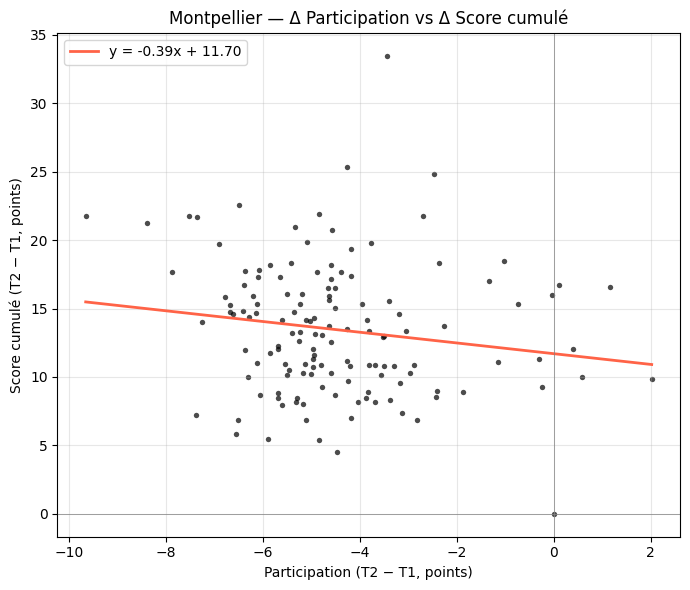

In [40]:

# Lille
df_lille = analyse_ville(t1, t2, "Lille", "59", "59350", ["LILLE INSOUMISE, ÉCOLOGISTE ET POPULAIRE"], ["LILLE INSOUMISE, ÉCOLOGISTE ET POPULAIRE"], "Augmentation de la participation", "Augmentation du score de la liste LFI")


# Nantes
df_nantes = analyse_ville(t1, t2, "Nantes", "44", "44109", ["La gauche unie pour Nantes","Nouvelle Nantes","Nantes Populaire"], ["La gauche unie pour Nantes"], "Augmentation de la participation", "Augmentation du score de la liste LFI")

# Montpellier
_ = analyse_ville(t1, t2, "Montpellier", "34", "34172", ["FAIRE MIEUX POUR MONTPELLIER"], ["FAIRE MIEUX POUR MONTPELLIER"], "Augmentation de la participation", "Augmentation du score de la liste LFI")
_ = analyse_ville(t1, t2, "Montpellier", "34", "34172", ["DEMAIN MONTPELLIER"], ["DEMAIN MONTPELLIER"])
_ = analyse_ville(t1, t2, "Montpellier", "34", "34172", ["MONTPELLIER NOTRE FIERTÉ"], ["MONTPELLIER NOTRE FIERTÉ"])

T1 : 903 bureaux de vote pour Paris
  Libellés recherchés : ['LNPP']
  Score trouvé dans 903/903 bureaux
T2 : 903 bureaux de vote pour Paris
  Libellés recherchés : ['LNPP']
  Score trouvé dans 903/903 bureaux


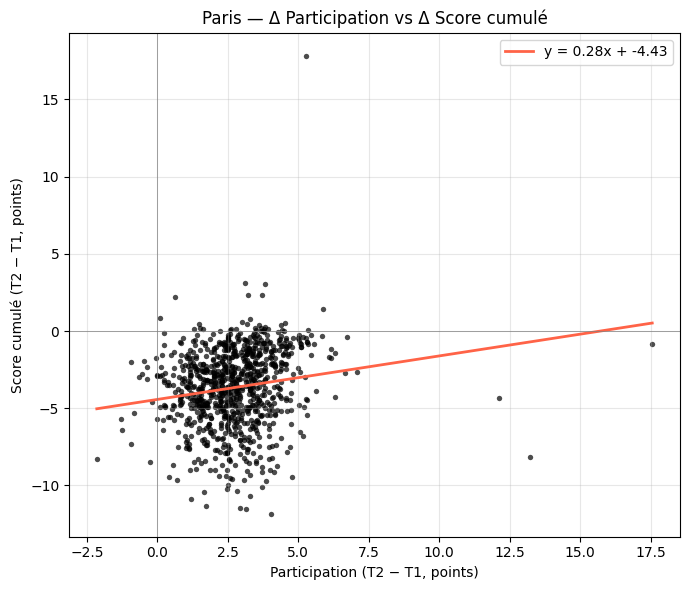

T1 : 115 bureaux de vote pour Rennes
  Libellés recherchés : ['FAIRE MIEUX POUR RENNES, UNION POPULAIRE ET ÉCOLOGISTE']
  Score trouvé dans 115/115 bureaux
T2 : 115 bureaux de vote pour Rennes
  Libellés recherchés : ['FAIRE MIEUX POUR RENNES, UNION POPULAIRE ET ÉCOLOGISTE']
  Score trouvé dans 115/115 bureaux


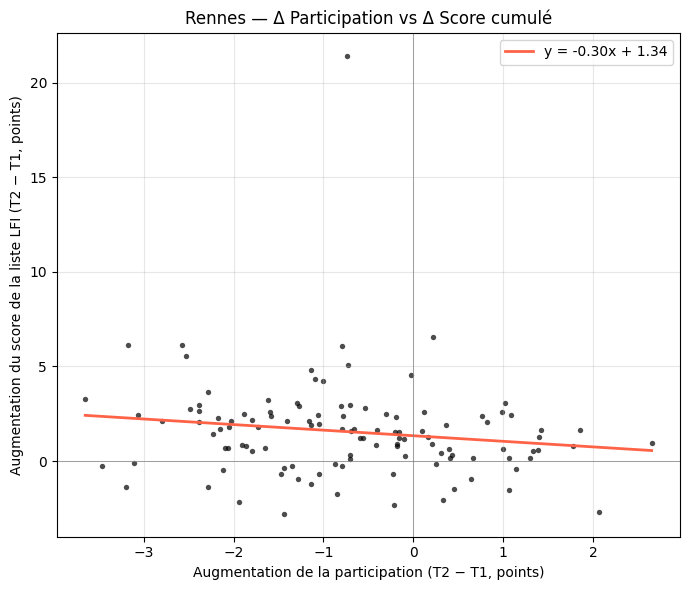

In [44]:

_ = analyse_ville(t1, t2, "Paris", "75", "75056", ["LNPP"], ["LNPP"])
_ = analyse_ville(t1, t2, "Rennes", "35", "35238", ["FAIRE MIEUX POUR RENNES, UNION POPULAIRE ET ÉCOLOGISTE"], ["FAIRE MIEUX POUR RENNES, UNION POPULAIRE ET ÉCOLOGISTE"], "Augmentation de la participation", "Augmentation du score de la liste LFI")

T1 : 110 bureaux de vote pour Le Havre
  Libellés recherchés : ['Avec Jean-Paul LECOQ, mieux vivre ensemble au Havre']
  Score trouvé dans 110/110 bureaux
T2 : 110 bureaux de vote pour Le Havre
  Libellés recherchés : ['Avec Jean-Paul LECOQ, mieux vivre ensemble au Havre']
  Score trouvé dans 110/110 bureaux


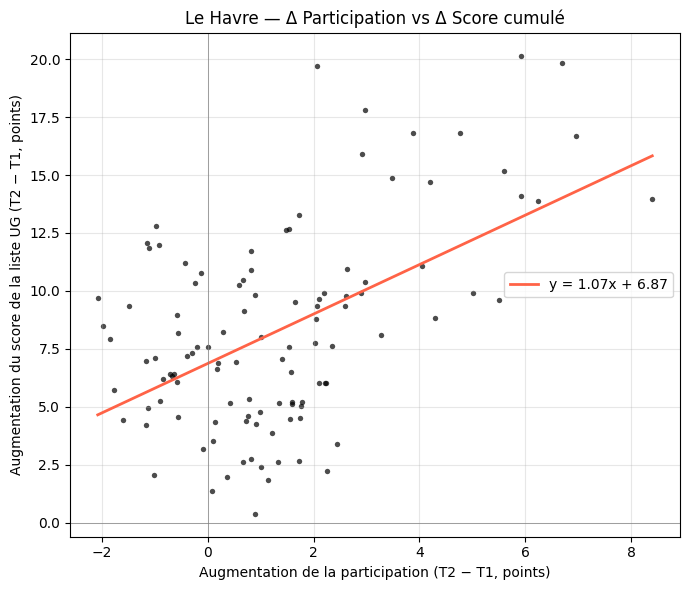

T1 : 86 bureaux de vote pour Nîmes
  Libellés recherchés : ['Nîmes en commun']
  Score trouvé dans 86/86 bureaux
T2 : 86 bureaux de vote pour Nîmes
  Libellés recherchés : ['Nîmes en commun']
  Score trouvé dans 86/86 bureaux


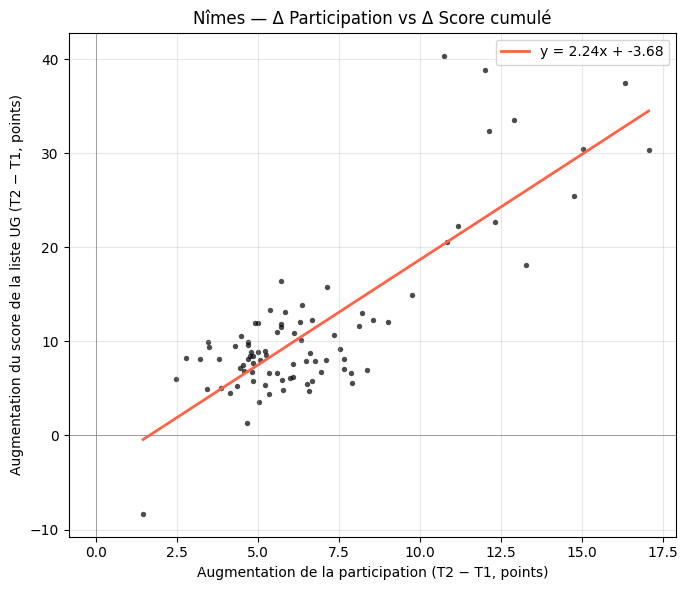

T1 : 68 bureaux de vote pour Besançon
  Libellés recherchés : ['FAIRE MIEUX POUR BESANÇON', 'BESANCON : VIVANTE, JUSTE ET HUMAINE']
  Score trouvé dans 68/68 bureaux
T2 : 68 bureaux de vote pour Besançon
  Libellés recherchés : ['BESANCON : VIVANTE, JUSTE ET HUMAINE']
  Score trouvé dans 68/68 bureaux


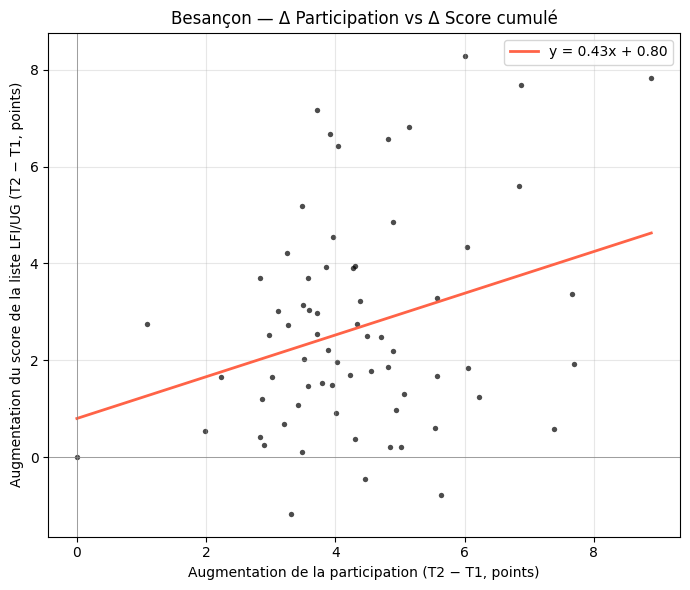

T1 : 70 bureaux de vote pour Clermont-Ferrand
  Libellés recherchés : ['VIVRE CLERMONT !', 'Clermont-Fd Fière et Solidaire']
  Score trouvé dans 70/70 bureaux
T2 : 70 bureaux de vote pour Clermont-Ferrand
  Libellés recherchés : ['VIVRE CLERMONT !']
  Score trouvé dans 70/70 bureaux


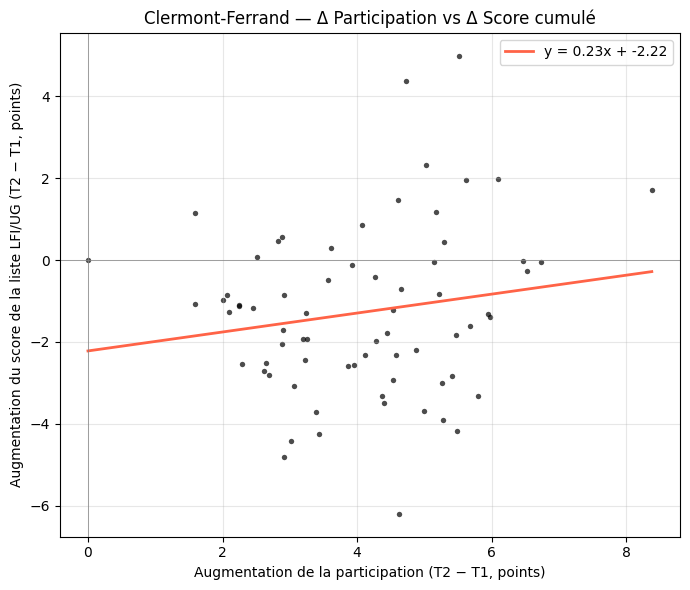

T1 : 86 bureaux de vote pour Limoges
  Libellés recherchés : ['Limoges Front Populaire - Union de la gauche sociale et écologiste', 'POUR LIMOGES THIERRY MIGUEL']
  Score trouvé dans 86/86 bureaux
T2 : 86 bureaux de vote pour Limoges
  Libellés recherchés : ['Pour Limoges : Front Populaire - Union de la gauche sociale et écologiste']
  Score trouvé dans 86/86 bureaux


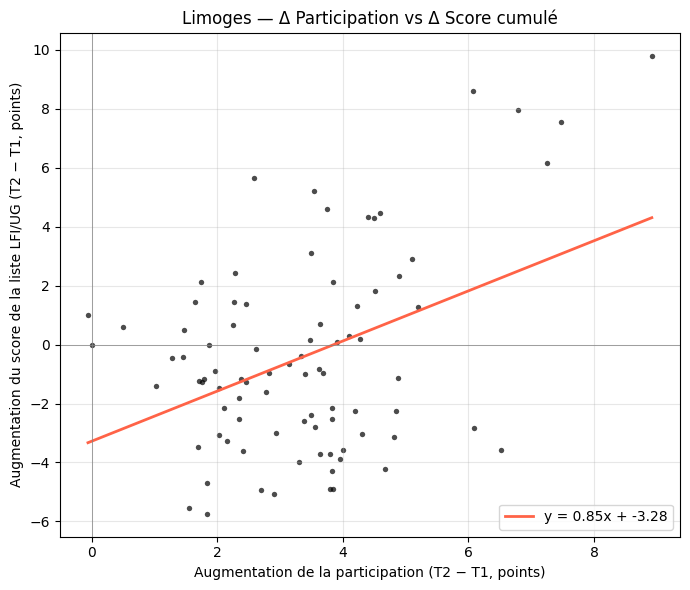

In [50]:

_ = analyse_ville(t1, t2, "Le Havre", "76", "76351", ["Avec Jean-Paul LECOQ, mieux vivre ensemble au Havre"], ["Avec Jean-Paul LECOQ, mieux vivre ensemble au Havre"], "Augmentation de la participation", "Augmentation du score de la liste UG")

_ = analyse_ville(t1, t2, "Nîmes", "30", "30189", ["Nîmes en commun"], ["Nîmes en commun"], "Augmentation de la participation", "Augmentation du score de la liste UG")

_ = analyse_ville(t1, t2, "Besançon", "25", "25056", ["FAIRE MIEUX POUR BESANÇON","BESANCON : VIVANTE, JUSTE ET HUMAINE"], ["BESANCON : VIVANTE, JUSTE ET HUMAINE"], "Augmentation de la participation", "Augmentation du score de la liste LFI/UG")



_ = analyse_ville(t1, t2, "Clermont-Ferrand", "63", "63113", ["VIVRE CLERMONT !","Clermont-Fd Fière et Solidaire"], ["VIVRE CLERMONT !"], "Augmentation de la participation", "Augmentation du score de la liste LFI/UG")


_ = analyse_ville(t1, t2, "Limoges", "87", "87085", ["Limoges Front Populaire - Union de la gauche sociale et écologiste", "POUR LIMOGES THIERRY MIGUEL"], ["Pour Limoges : Front Populaire - Union de la gauche sociale et écologiste"], "Augmentation de la participation", "Augmentation du score de la liste LFI/UG")

In [65]:
def analyse_transfert(t1, t2, ville, code_dept, code_commune,
                      label_axe_x,        # libellé abrégé de la liste A (axe X, score T1)
                      labels_t1,           # libellés des listes pour le score cumulé T1
                      labels_t2,           # libellés des listes pour le score cumulé T2
                      title="Reports de voix",
                      xaxis ="Score A au T1 (%)",
                      yaxis="Δ Score cumulé T2 − T1 (points)",
                      part_min=0):
    """
    Scatter plot : score d'une liste A au T1 (axe X) vs delta du score cumulé entre T2 et T1 (axe Y).
    """
    
    def extract_full(df, tour, labels, label_extra=None):
        mask = (df["Code département"] == code_dept) & (df["Code commune"] == code_commune)
        toul = df[mask].copy()
        if toul.empty:
            mask = df["Libellé commune"].str.contains(ville, case=False, na=False)
            toul = df[mask].copy()
        
        toul["% Votants"] = toul["% Votants"].str.replace(",", ".").str.replace("%", "").astype(float)
        
        labels_upper = [l.upper().strip() for l in labels]
        extra_upper = label_extra.upper().strip() if label_extra else None
        
        scores = []
        scores_extra = []
        for _, row in toul.iterrows():
            total = 0.0
            found = []
            extra_score = None
            for i in range(1, 14):
                col_label = f"Libellé abrégé de liste {i}"
                col_voix_pct = f"% Voix/exprimés {i}"
                if col_label in row.index and pd.notna(row[col_label]):
                    label = str(row[col_label]).upper().strip()
                    if label in labels_upper:
                        val = row[col_voix_pct]
                        if pd.notna(val) and val != "":
                            total += float(str(val).replace(",", ".").replace("%", ""))
                            found.append(label)
                    if extra_upper and label == extra_upper:
                        val = row[col_voix_pct]
                        if pd.notna(val) and val != "":
                            extra_score = float(str(val).replace(",", ".").replace("%", ""))
            scores.append(total if found else None)
            scores_extra.append(extra_score)
        
        toul["Score"] = scores
        toul["Score_extra"] = scores_extra
        result = toul[["Code BV", "% Votants", "Score", "Score_extra"]].copy()
        result = result.rename(columns={"% Votants": "Participation"})
        return result
    
    # T1 : on extrait le score cumulé des listes X ET le score de la liste A
    res_t1 = extract_full(t1, "T1", labels_t1, label_extra=label_axe_x)
    res_t1 = res_t1.rename(columns={
        "Participation": "Participation_T1",
        "Score": "Score_T1",
        "Score_extra": "Score_A_T1"
    })
    
    # T2 : on extrait juste le score cumulé des listes Y
    res_t2 = extract_full(t2, "T2", labels_t2)
    res_t2 = res_t2.rename(columns={
        "Participation": "Participation_T2",
        "Score": "Score_T2"
    })
    res_t2 = res_t2[["Code BV", "Participation_T2", "Score_T2"]]
    
    merged = pd.merge(res_t1, res_t2, on="Code BV", how="outer").sort_values("Code BV").reset_index(drop=True)
    
    # Filtrage
    temp = merged.dropna(subset=["Score_A_T1", "Score_T1", "Score_T2", "Participation_T1", "Participation_T2"])
    temp = temp[(temp["Participation_T1"] >= part_min) & (temp["Participation_T2"] >= part_min) & (temp["Score_A_T1"] >= 1)]
    
    x = temp["Score_A_T1"].values
    y = (temp["Score_T2"] - temp["Score_T1"]).values
    
    print(f"{ville} : {len(x)} bureaux de vote retenus")
    
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(x, y, alpha=0.7, s=15, color="black", linewidths=0)
    
    if len(x) > 1:
        coeffs = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, np.polyval(coeffs, x_line), color="tomato", linewidth=2,
                label=f"y = {coeffs[0]:.2f}x + {coeffs[1]:.2f}")
        ax.legend()
    
    #ax.axhline(0, color="grey", linewidth=0.5)
    ax.set_xlabel(f"{xaxis}")
    ax.set_ylabel(f"{yaxis}")
    ax.set_title(f"{ville} — {title}")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return merged

Toulouse : 284 bureaux de vote retenus


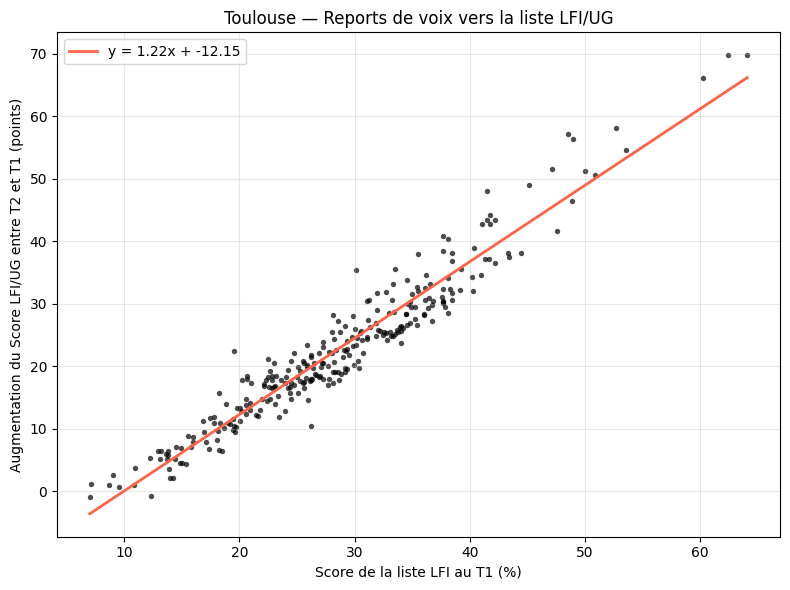

Toulouse : 284 bureaux de vote retenus


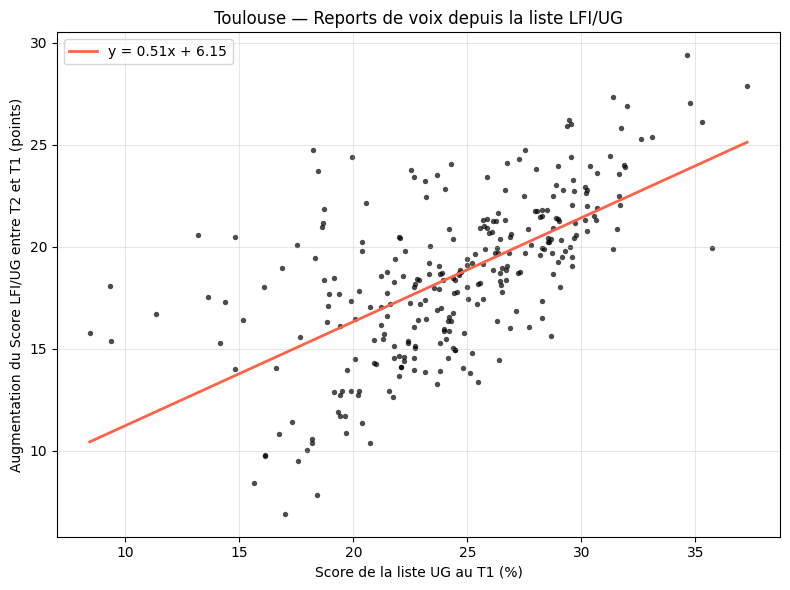

Toulouse : 284 bureaux de vote retenus


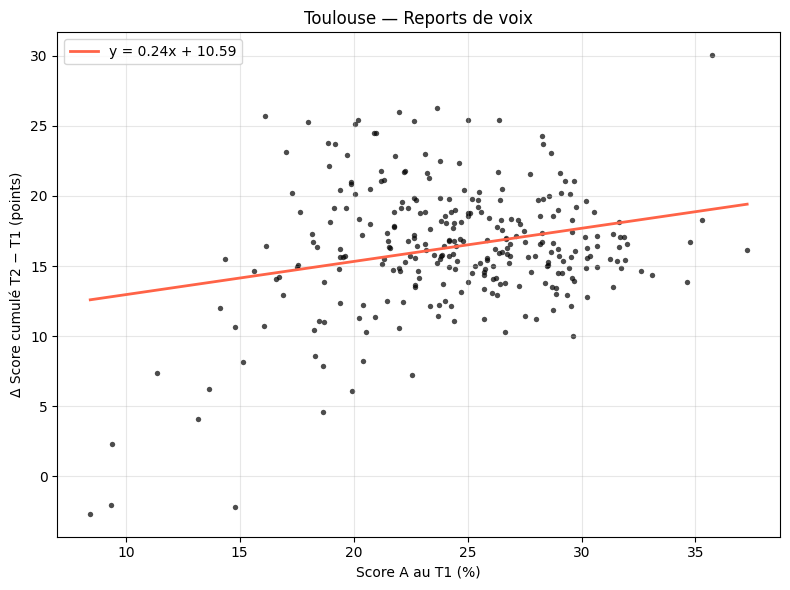

In [66]:
# Toulouse
df_toulouse = analyse_transfert(t1, t2, "Toulouse", "31", "31555","Demain Toulouse à gauche et écologiste", ["Vivre mieux La gauche unie, écologiste, citoyenne et solidaire"], ["Demain Toulouse La Gauche Unie"], "Reports de voix vers la liste LFI/UG", "Score de la liste LFI au T1 (%)", "Augmentation du Score LFI/UG entre T2 et T1 (points)", part_min=0)
# Toulouse
df_toulouse = analyse_transfert(t1, t2, "Toulouse", "31", "31555","Vivre mieux La gauche unie, écologiste, citoyenne et solidaire", ["Demain Toulouse à gauche et écologiste"], ["Demain Toulouse La Gauche Unie"], "Reports de voix depuis la liste LFI/UG", "Score de la liste UG au T1 (%)", "Augmentation du Score LFI/UG entre T2 et T1 (points)", part_min=0)


df_toulouse = analyse_transfert(t1, t2, "Toulouse", "31", "31555","Vivre mieux La gauche unie, écologiste, citoyenne et solidaire", ["Avec Jean-Luc MOUDENC, Protégeons l'Avenir de Toulouse"], ["Avec Jean-Luc MOUDENC, Protégeons l'Avenir de Toulouse"])

Limoges : 85 bureaux de vote retenus


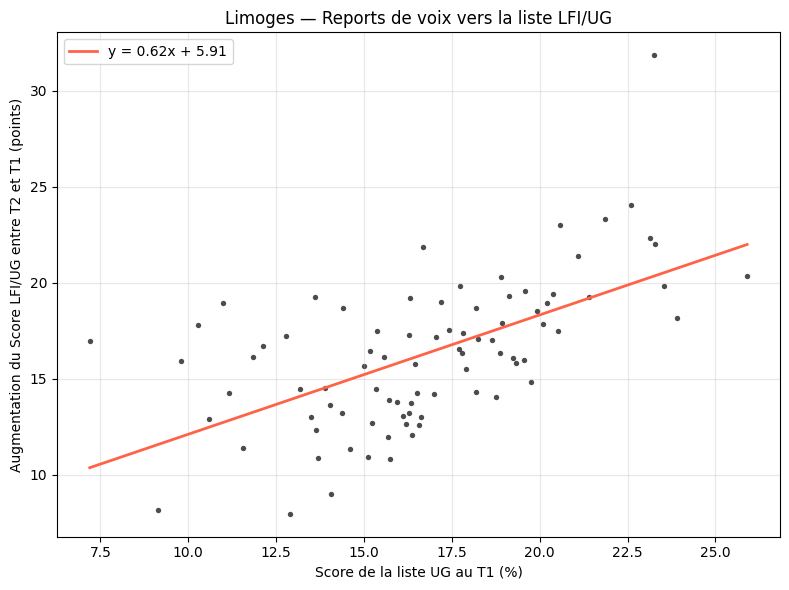

Limoges : 85 bureaux de vote retenus


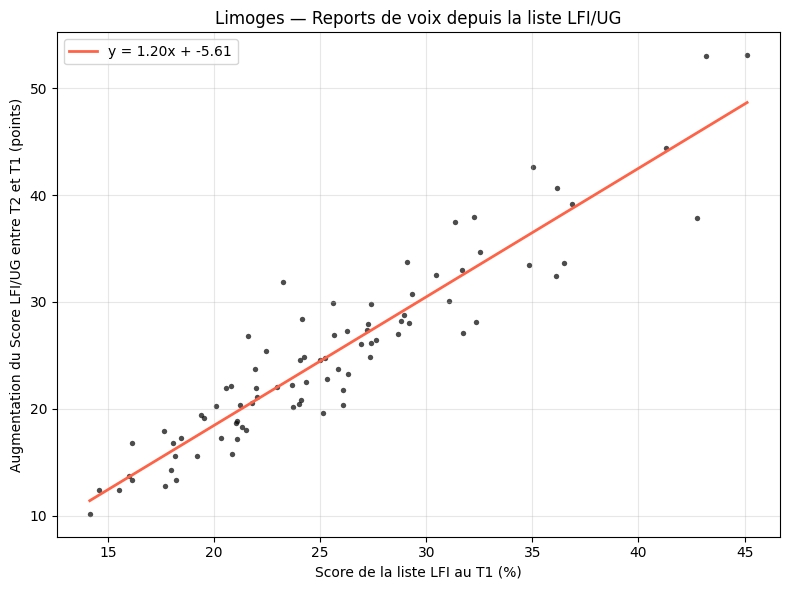

In [67]:
df_toulouse = analyse_transfert(t1, t2, "Limoges", "87", "87085","POUR LIMOGES THIERRY MIGUEL", ["Limoges Front Populaire - Union de la gauche sociale et écologiste"], ["Pour Limoges : Front Populaire - Union de la gauche sociale et écologiste"], "Reports de voix vers la liste LFI/UG", "Score de la liste UG au T1 (%)", "Augmentation du Score LFI/UG entre T2 et T1 (points)", part_min=0)
# Toulouse
df_toulouse = analyse_transfert(t1, t2, "Limoges", "87", "87085","Limoges Front Populaire - Union de la gauche sociale et écologiste", ["POUR LIMOGES THIERRY MIGUEL"], ["Pour Limoges : Front Populaire - Union de la gauche sociale et écologiste"], "Reports de voix depuis la liste LFI/UG", "Score de la liste LFI au T1 (%)", "Augmentation du Score LFI/UG entre T2 et T1 (points)", part_min=0)
# Toulouse

Besançon : 67 bureaux de vote retenus


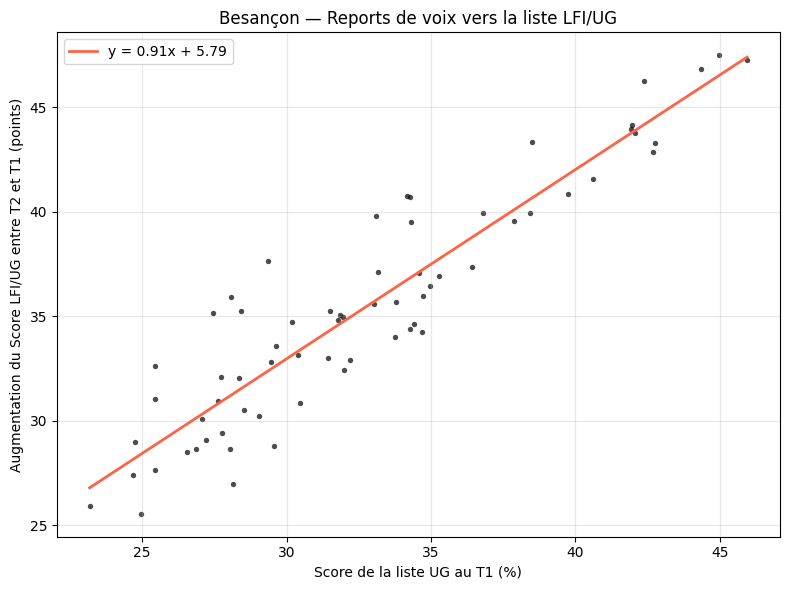

Besançon : 67 bureaux de vote retenus


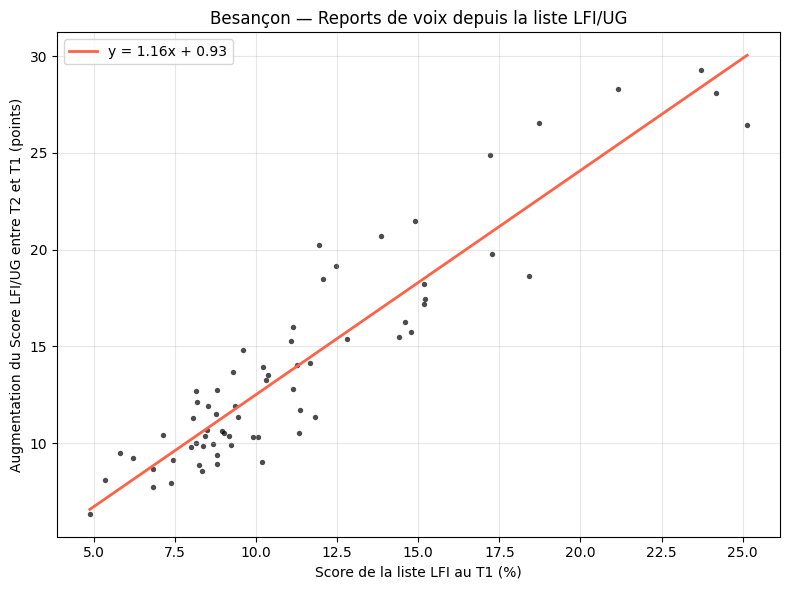

In [68]:
df_toulouse = analyse_transfert(t1, t2, "Besançon", "25", "25056","BESANCON : VIVANTE, JUSTE ET HUMAINE", ["FAIRE MIEUX POUR BESANÇON"], ["BESANCON : VIVANTE, JUSTE ET HUMAINE"], "Reports de voix vers la liste LFI/UG", "Score de la liste UG au T1 (%)", "Augmentation du Score LFI/UG entre T2 et T1 (points)", part_min=0)
# Toulouse
df_toulouse = analyse_transfert(t1, t2, "Besançon", "25", "25056","FAIRE MIEUX POUR BESANÇON", ["BESANCON : VIVANTE, JUSTE ET HUMAINE"], ["BESANCON : VIVANTE, JUSTE ET HUMAINE"], "Reports de voix depuis la liste LFI/UG", "Score de la liste LFI au T1 (%)", "Augmentation du Score LFI/UG entre T2 et T1 (points)", part_min=0)

# Toulouse

Brest : 105 bureaux de vote retenus


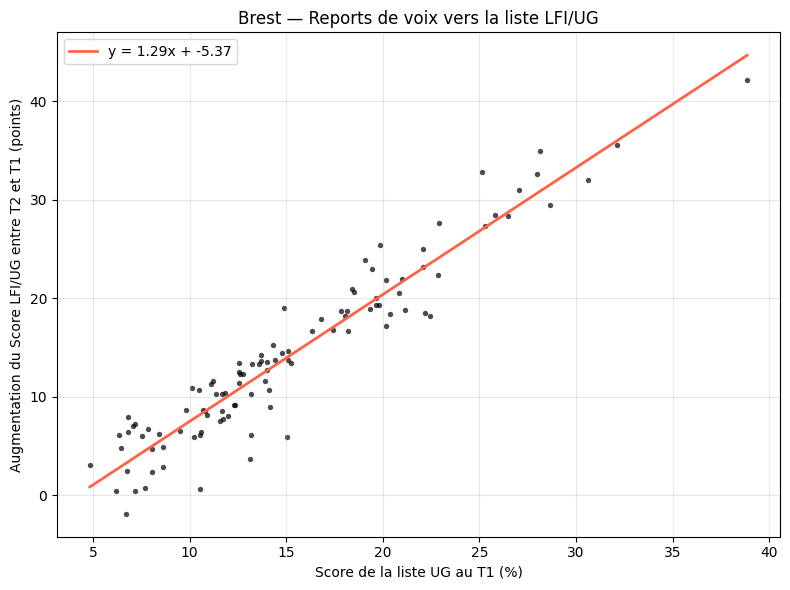

Brest : 105 bureaux de vote retenus


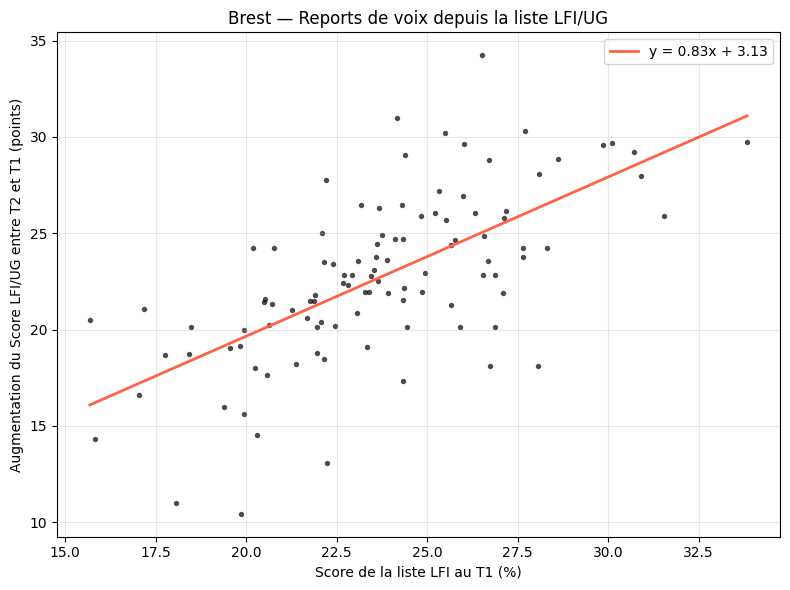

In [69]:
df_toulouse = analyse_transfert(t1, t2, "Brest", "29", "29019","Brest insoumise", ["La gauche unie pour Brest"], ["La gauche unie pour Brest"], "Reports de voix vers la liste LFI/UG", "Score de la liste UG au T1 (%)", "Augmentation du Score LFI/UG entre T2 et T1 (points)", part_min=0)
# Brest
df_toulouse = analyse_transfert(t1, t2, "Brest", "29", "29019","La gauche unie pour Brest", ["Brest insoumise"], ["La gauche unie pour Brest"], "Reports de voix depuis la liste LFI/UG", "Score de la liste LFI au T1 (%)", "Augmentation du Score LFI/UG entre T2 et T1 (points)", part_min=0)

# Toulouse

Clermont-Ferrand : 69 bureaux de vote retenus


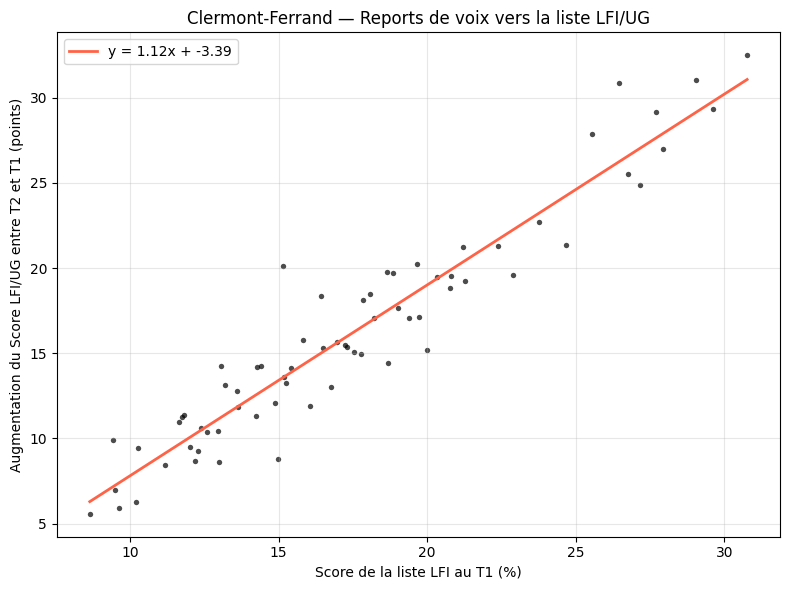

Clermont-Ferrand : 69 bureaux de vote retenus


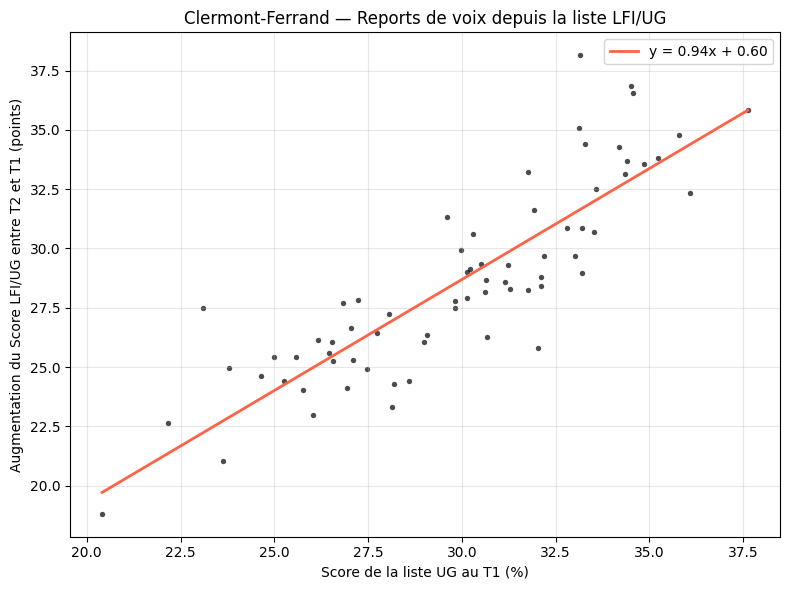

In [70]:
df_toulouse = analyse_transfert(t1, t2, "Clermont-Ferrand", "63", "63113","Clermont-Fd Fière et Solidaire", ["VIVRE CLERMONT !"], ["VIVRE CLERMONT !"], "Reports de voix vers la liste LFI/UG", "Score de la liste LFI au T1 (%)", "Augmentation du Score LFI/UG entre T2 et T1 (points)", part_min=0)
# Clermont-Ferrand
df_toulouse = analyse_transfert(t1, t2, "Clermont-Ferrand", "63", "63113","VIVRE CLERMONT !", ["Clermont-Fd Fière et Solidaire"], ["VIVRE CLERMONT !"], "Reports de voix depuis la liste LFI/UG", "Score de la liste UG au T1 (%)", "Augmentation du Score LFI/UG entre T2 et T1 (points)", part_min=0)

Paris : 902 bureaux de vote retenus


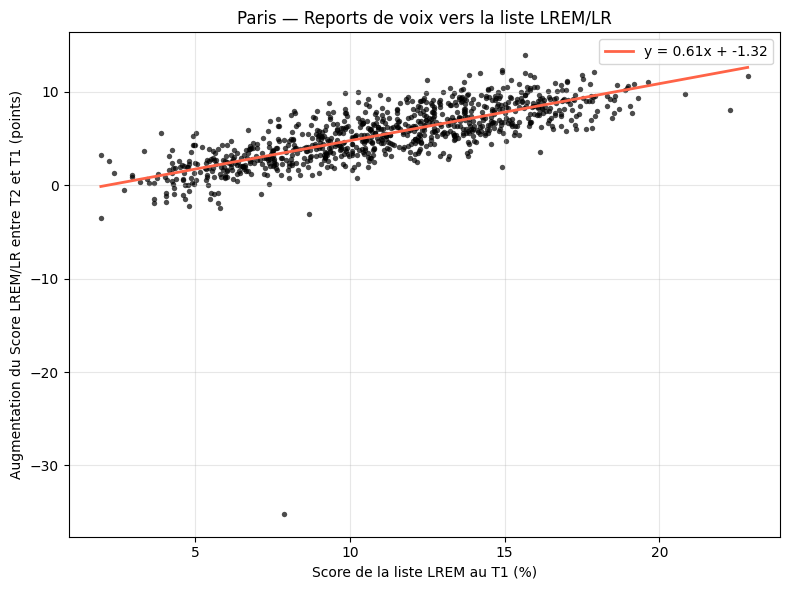

Paris : 902 bureaux de vote retenus


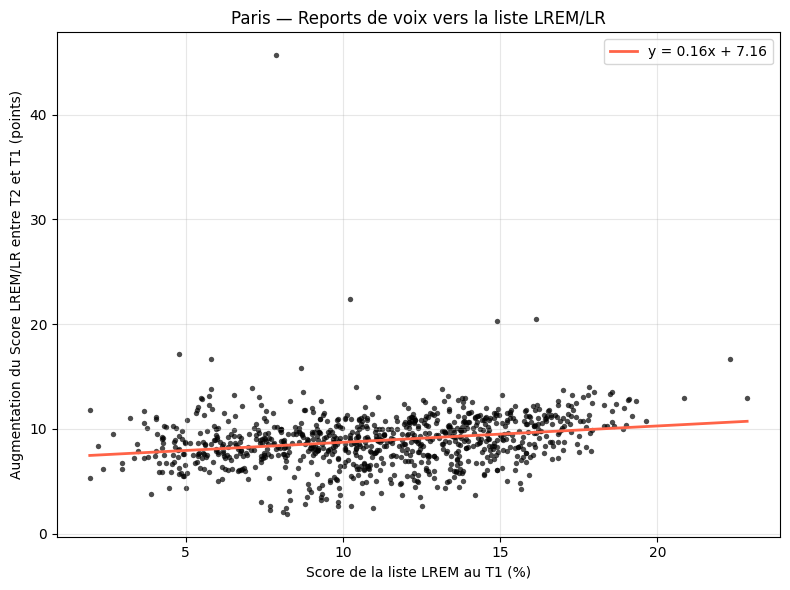

Paris : 903 bureaux de vote retenus


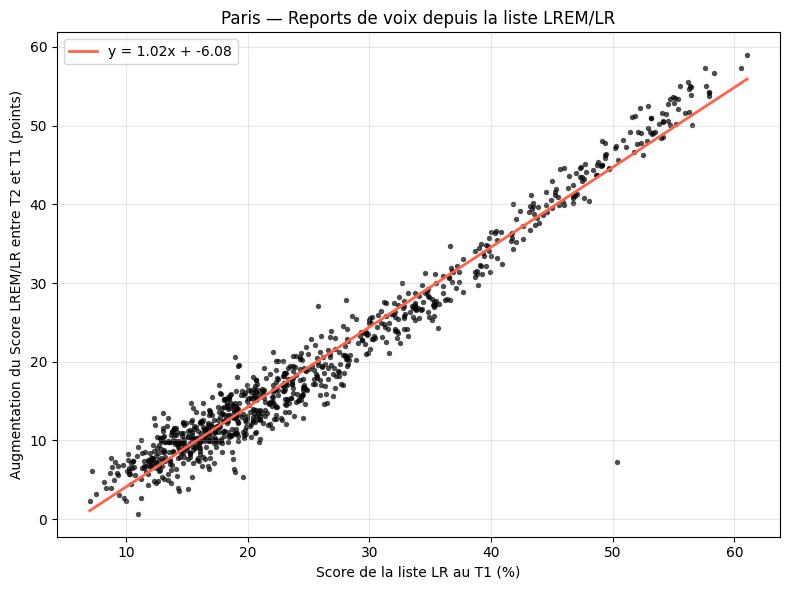

In [76]:
df_toulouse = analyse_transfert(t1, t2, "Paris", "75", "75056","PAAPYB", ["CPARD", "SK UVH"], ["CPARD"], "Reports de voix vers la liste LREM/LR", "Score de la liste LREM au T1 (%)", "Augmentation du Score LREM/LR entre T2 et T1 (points)", part_min=0)

df_toulouse = analyse_transfert(t1, t2, "Paris", "75", "75056","PAAPYB", ["EG", "LNPP"], ["EG", "LNPP"], "Reports de voix vers la liste LREM/LR", "Score de la liste LREM au T1 (%)", "Augmentation du Score LREM/LR entre T2 et T1 (points)", part_min=0)
# Paris
df_toulouse = analyse_transfert(t1, t2, "Paris", "75", "75056","CPARD", ["PAAPYB", "SK UVH"], ["CPARD"], "Reports de voix depuis la liste LREM/LR", "Score de la liste LR au T1 (%)", "Augmentation du Score LREM/LR entre T2 et T1 (points)", part_min=0)




Lille : 128 bureaux de vote retenus


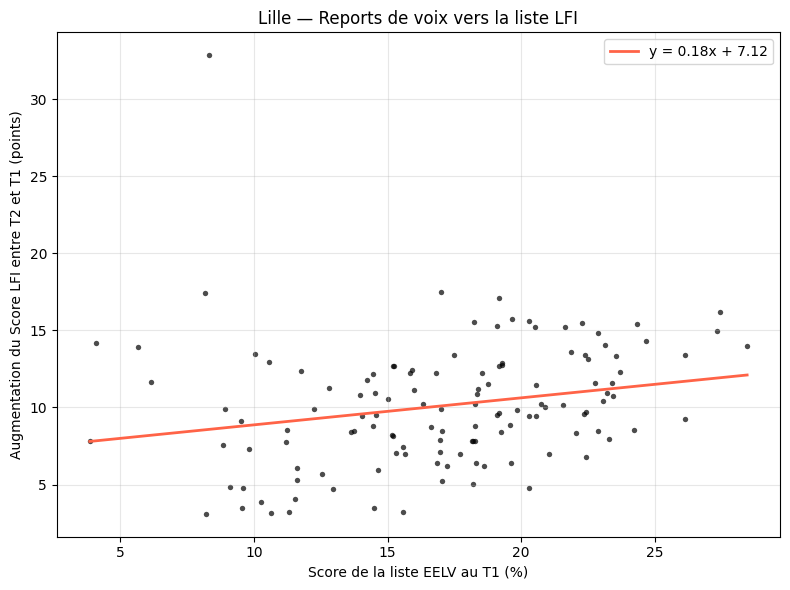

Lille : 128 bureaux de vote retenus


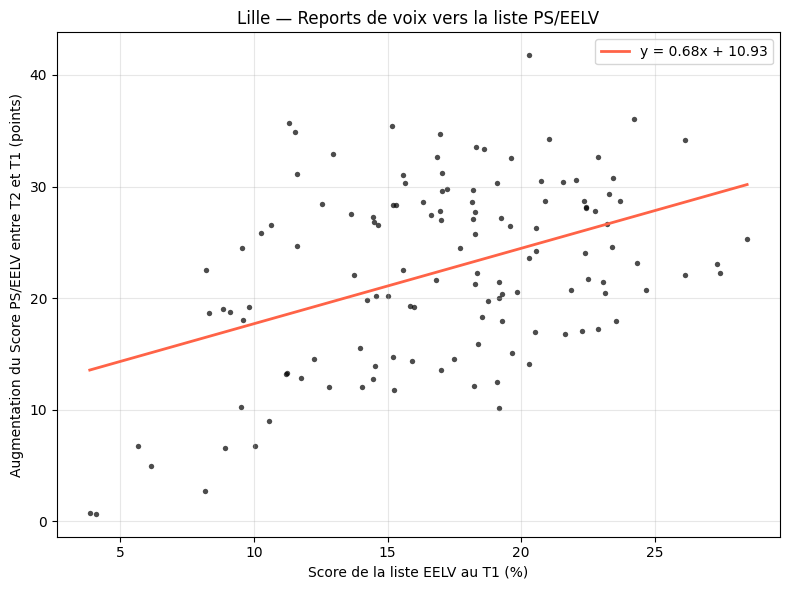

Lille : 128 bureaux de vote retenus


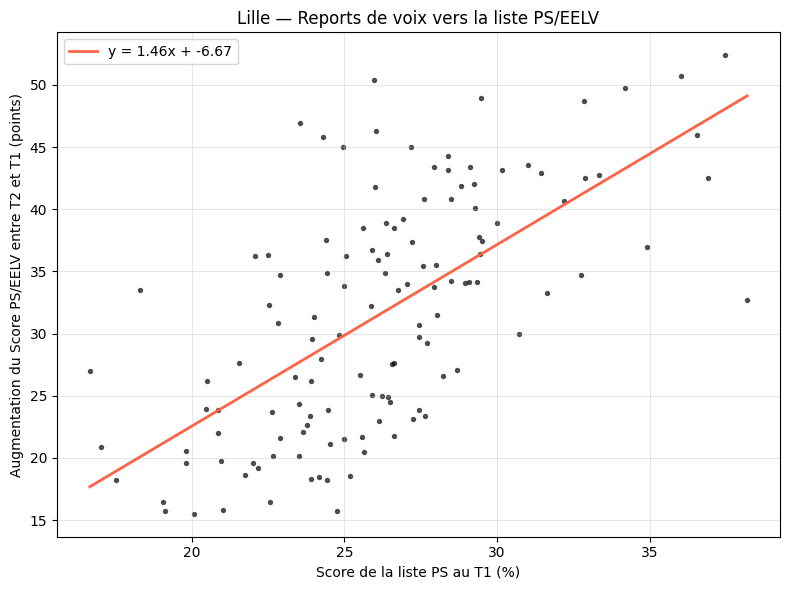

In [81]:
df_toulouse = analyse_transfert(t1, t2, "Lille", "59", "59350","Lille Demain avec Stéphane Baly", ["LILLE INSOUMISE, ÉCOLOGISTE ET POPULAIRE"], ["LILLE INSOUMISE, ÉCOLOGISTE ET POPULAIRE"], "Reports de voix vers la liste LFI", "Score de la liste EELV au T1 (%)", "Augmentation du Score LFI entre T2 et T1 (points)", part_min=0)

df_toulouse = analyse_transfert(t1, t2, "Lille", "59", "59350","Lille Demain avec Stéphane Baly", ["TOUT POUR LILLE"], ["TOUT POUR LILLE DEMAIN"], "Reports de voix vers la liste PS/EELV", "Score de la liste EELV au T1 (%)", "Augmentation du Score PS/EELV entre T2 et T1 (points)", part_min=0)



df_toulouse = analyse_transfert(t1, t2, "Lille", "59", "59350","TOUT POUR LILLE", ["Lille Demain avec Stéphane Baly"], ["TOUT POUR LILLE DEMAIN"], "Reports de voix vers la liste PS/EELV", "Score de la liste PS au T1 (%)", "Augmentation du Score PS/EELV entre T2 et T1 (points)", part_min=0)

Limoges : 85 bureaux de vote retenus


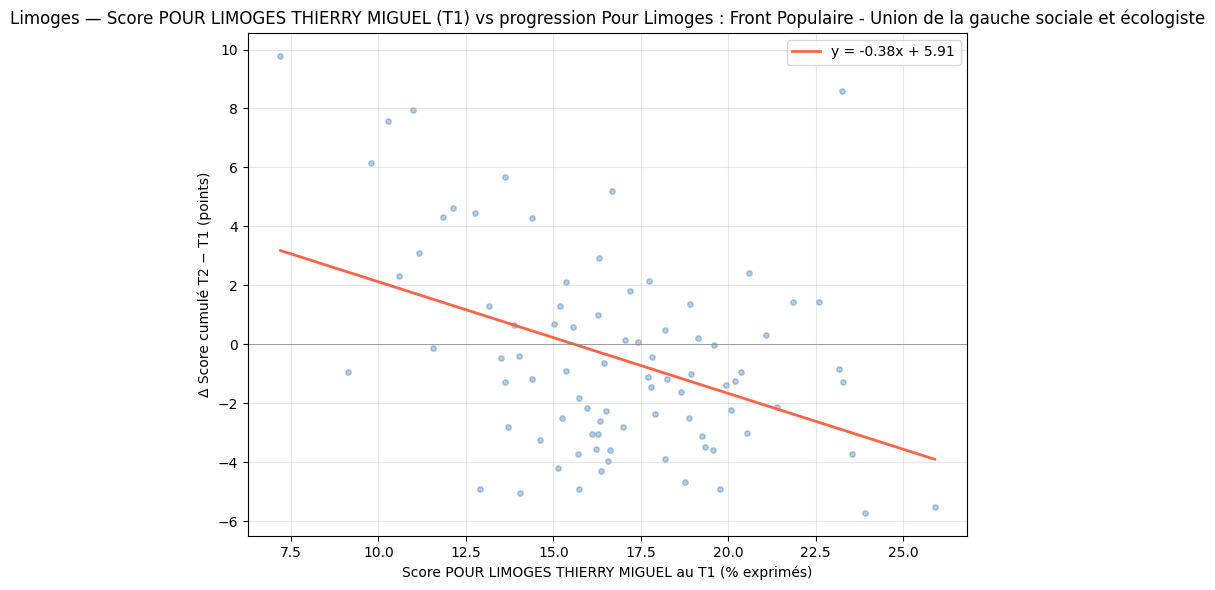

Limoges : 85 bureaux de vote retenus


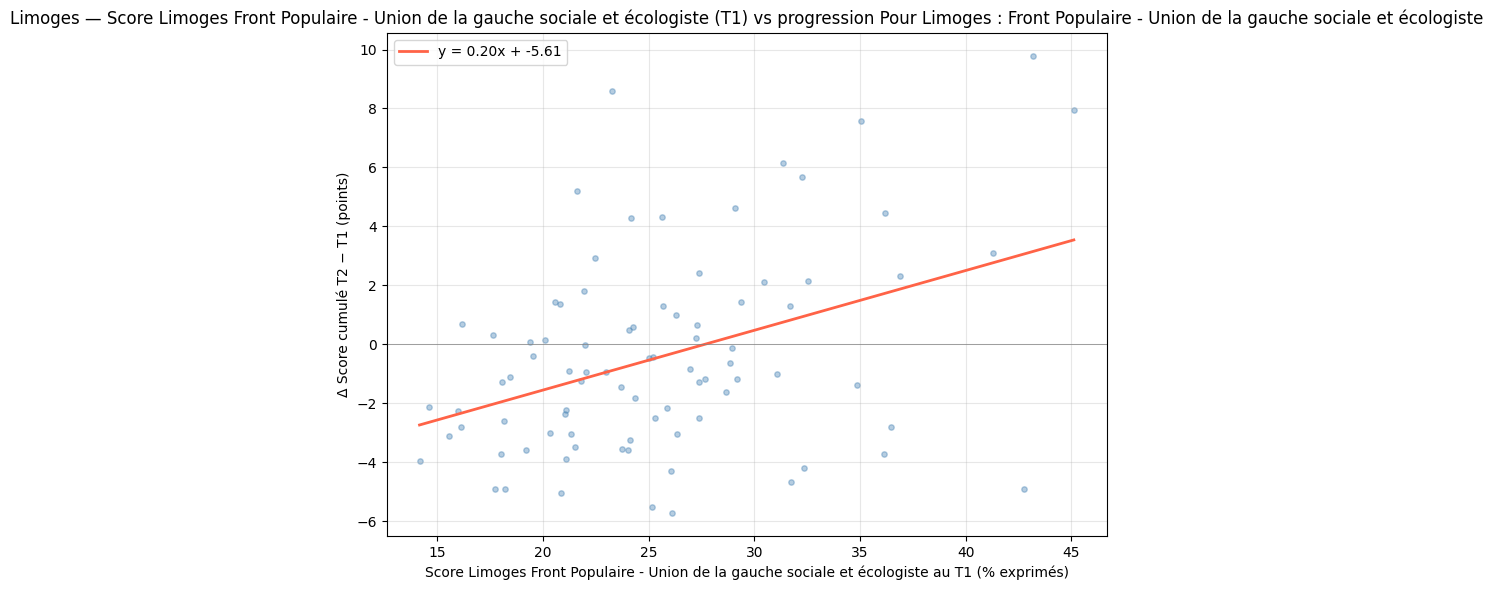

Limoges : 85 bureaux de vote retenus


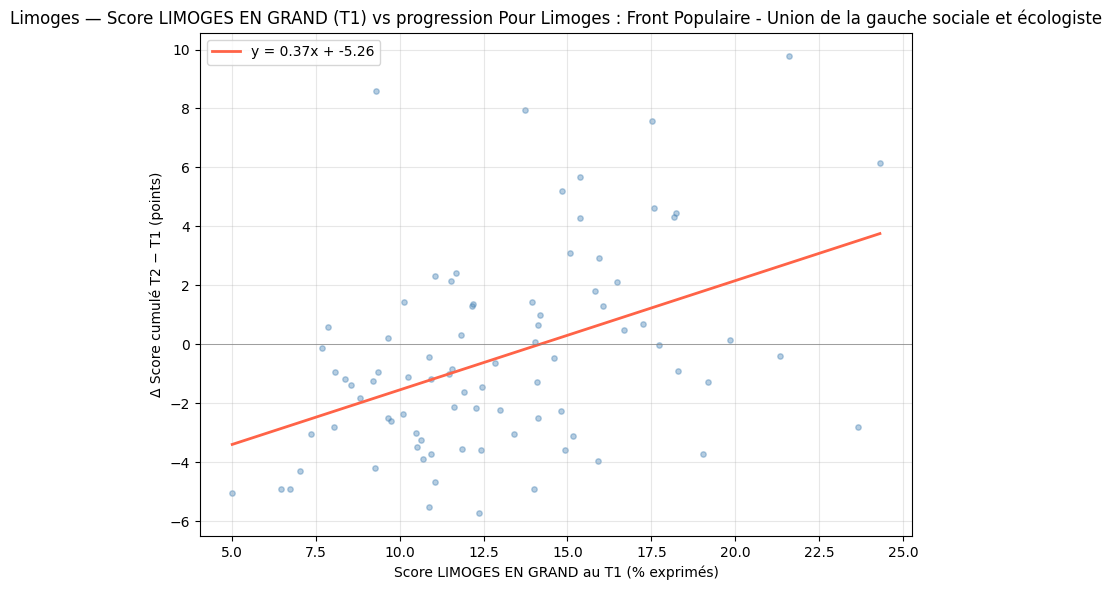

In [28]:

# Limoges
df_limoges = analyse_transfert(t1, t2, "Limoges", "87", "87085", "POUR LIMOGES THIERRY MIGUEL", ["POUR LIMOGES THIERRY MIGUEL", "Limoges Front Populaire - Union de la gauche sociale et écologiste"] , ["Pour Limoges : Front Populaire - Union de la gauche sociale et écologiste"])

# Limoges
df_limoges = analyse_transfert(t1, t2, "Limoges", "87", "87085", "Limoges Front Populaire - Union de la gauche sociale et écologiste", ["POUR LIMOGES THIERRY MIGUEL", "Limoges Front Populaire - Union de la gauche sociale et écologiste"] , ["Pour Limoges : Front Populaire - Union de la gauche sociale et écologiste"])

# Limoges
df_limoges = analyse_transfert(t1, t2, "Limoges", "87", "87085", "LIMOGES EN GRAND",  ["POUR LIMOGES THIERRY MIGUEL", "Limoges Front Populaire - Union de la gauche sociale et écologiste"] , ["Pour Limoges : Front Populaire - Union de la gauche sociale et écologiste"])

Marseille : 493 bureaux de vote retenus


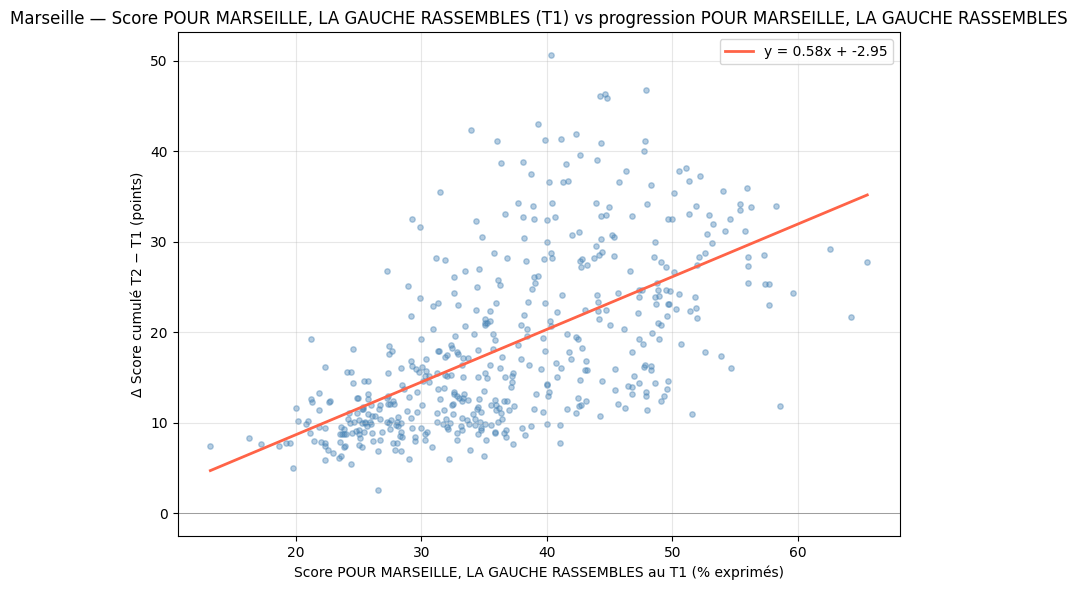

Marseille : 493 bureaux de vote retenus


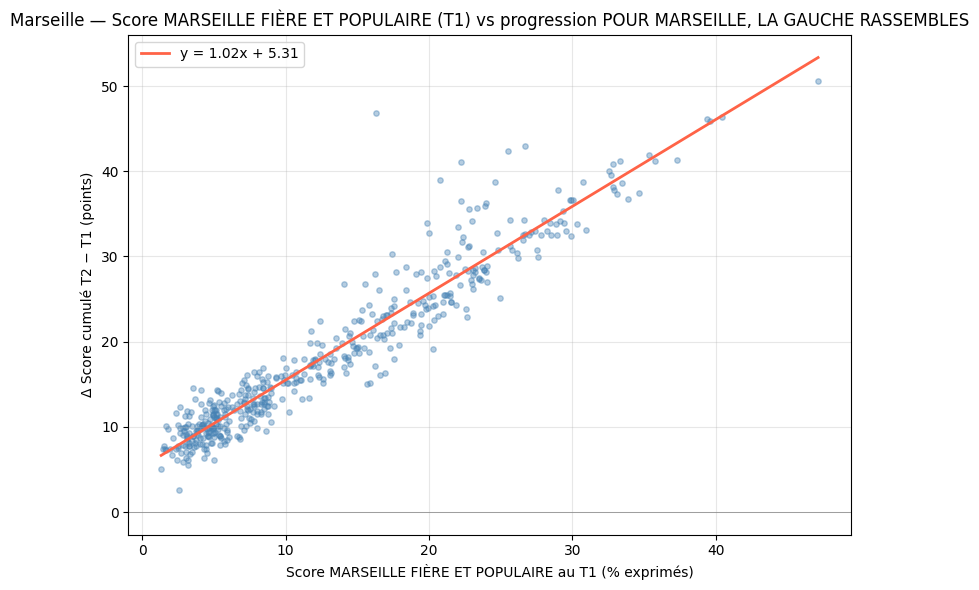

Marseille : 493 bureaux de vote retenus


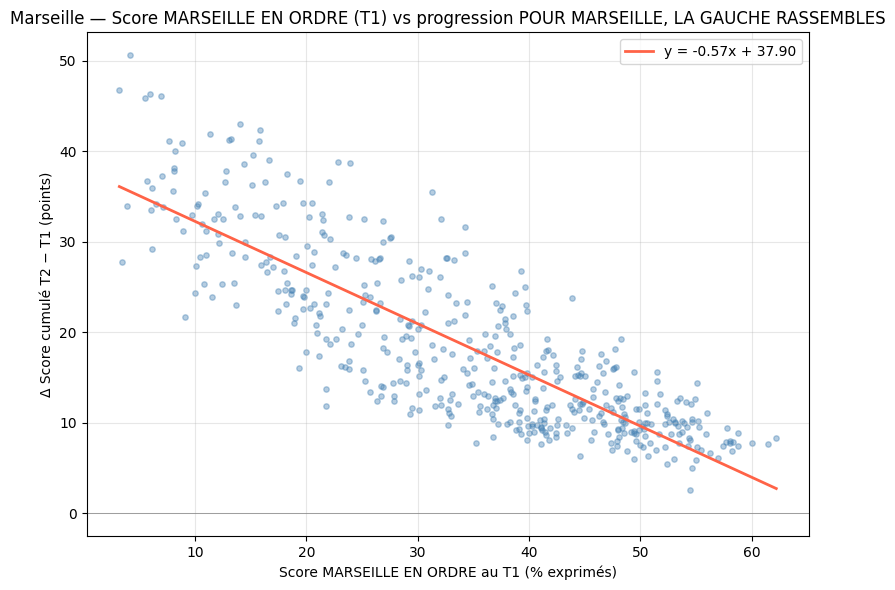

Marseille : 493 bureaux de vote retenus


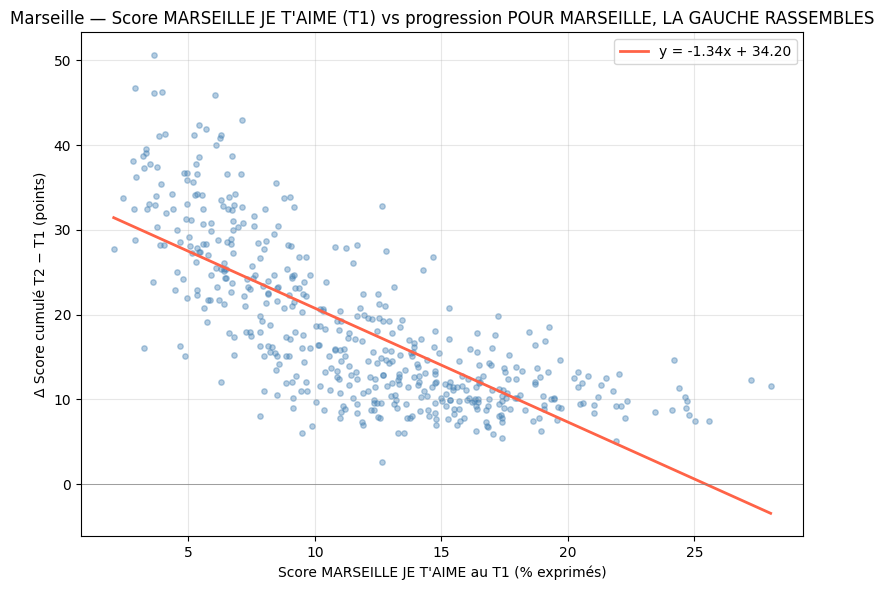

Marseille : 493 bureaux de vote retenus


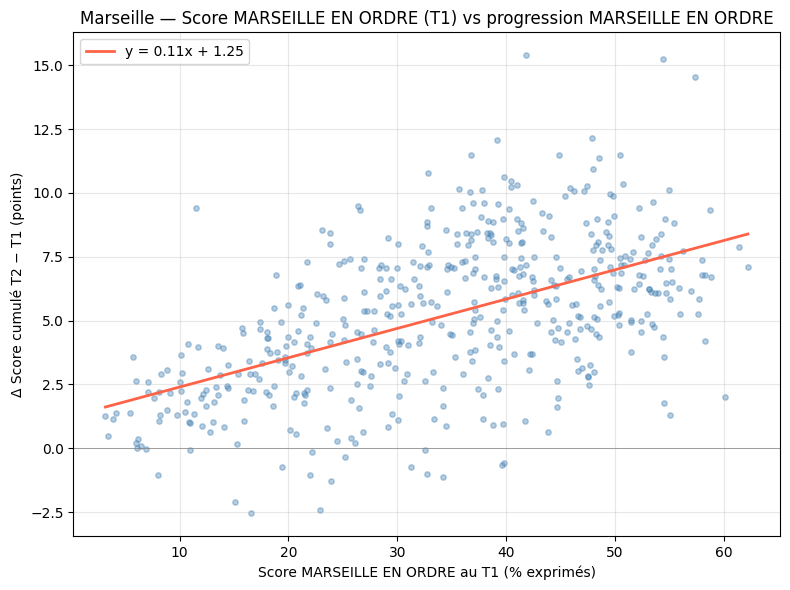

Marseille : 493 bureaux de vote retenus


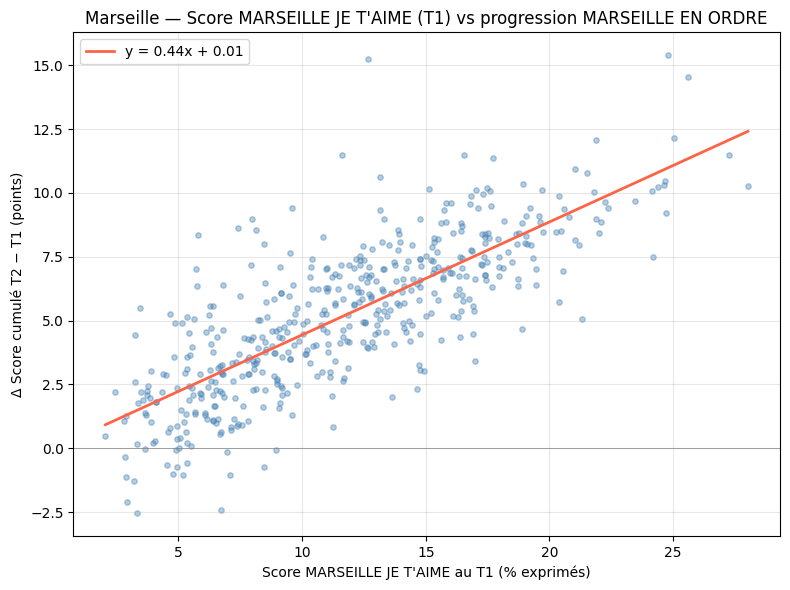

In [9]:

# Marseille
df_marseille = analyse_transfert(t1, t2, "Marseille", "13", "13055","POUR MARSEILLE, LA GAUCHE RASSEMBLES",["POUR MARSEILLE, LA GAUCHE RASSEMBLES"], ["POUR MARSEILLE, LA GAUCHE RASSEMBLES"])


# Marseille
df_marseille = analyse_transfert(t1, t2, "Marseille", "13", "13055","MARSEILLE FIÈRE ET POPULAIRE",["POUR MARSEILLE, LA GAUCHE RASSEMBLES"], ["POUR MARSEILLE, LA GAUCHE RASSEMBLES"])



# Marseille
df_marseille = analyse_transfert(t1, t2, "Marseille", "13", "13055","MARSEILLE EN ORDRE",["POUR MARSEILLE, LA GAUCHE RASSEMBLES"], ["POUR MARSEILLE, LA GAUCHE RASSEMBLES"])

# Marseille
df_marseille = analyse_transfert(t1, t2, "Marseille", "13", "13055","MARSEILLE JE T'AIME",["POUR MARSEILLE, LA GAUCHE RASSEMBLES"], ["POUR MARSEILLE, LA GAUCHE RASSEMBLES"])

# Marseille
df_marseille = analyse_transfert(t1, t2, "Marseille", "13", "13055","MARSEILLE EN ORDRE",["MARSEILLE EN ORDRE"], ["MARSEILLE EN ORDRE"])


df_marseille = analyse_transfert(t1, t2, "Marseille", "13", "13055","MARSEILLE JE T'AIME",["MARSEILLE EN ORDRE"], ["MARSEILLE EN ORDRE"])

Lyon : 312 bureaux de vote retenus


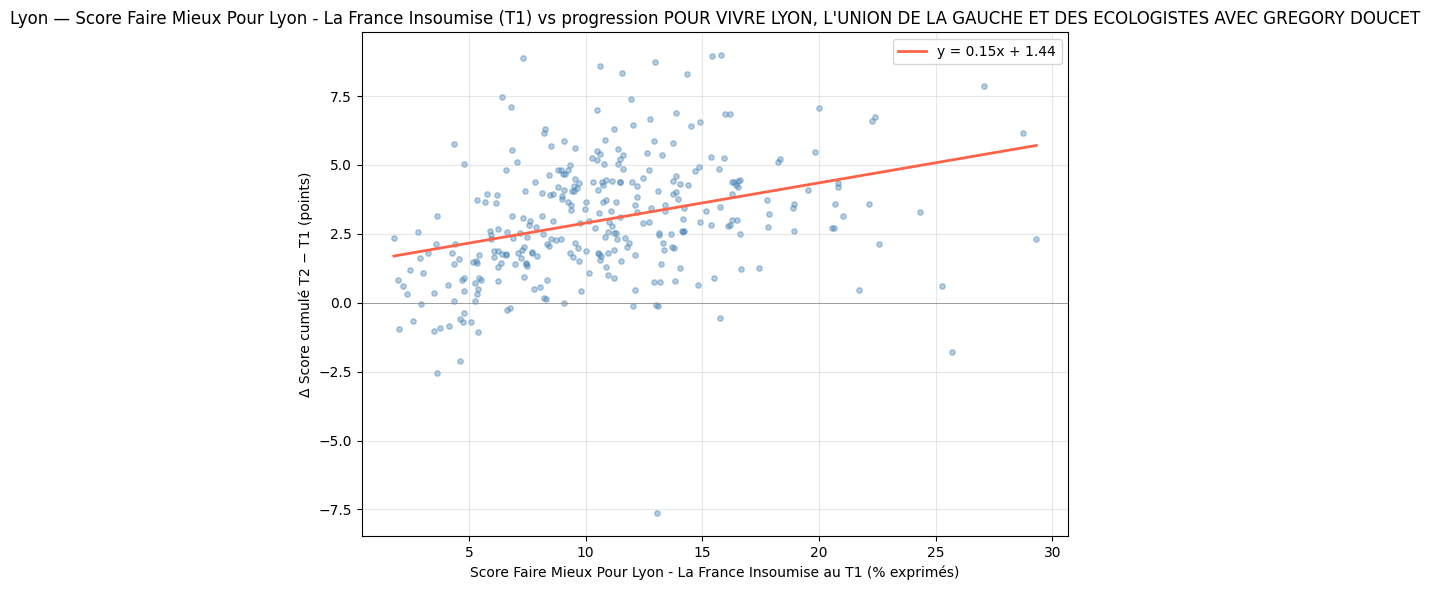

Lyon : 312 bureaux de vote retenus


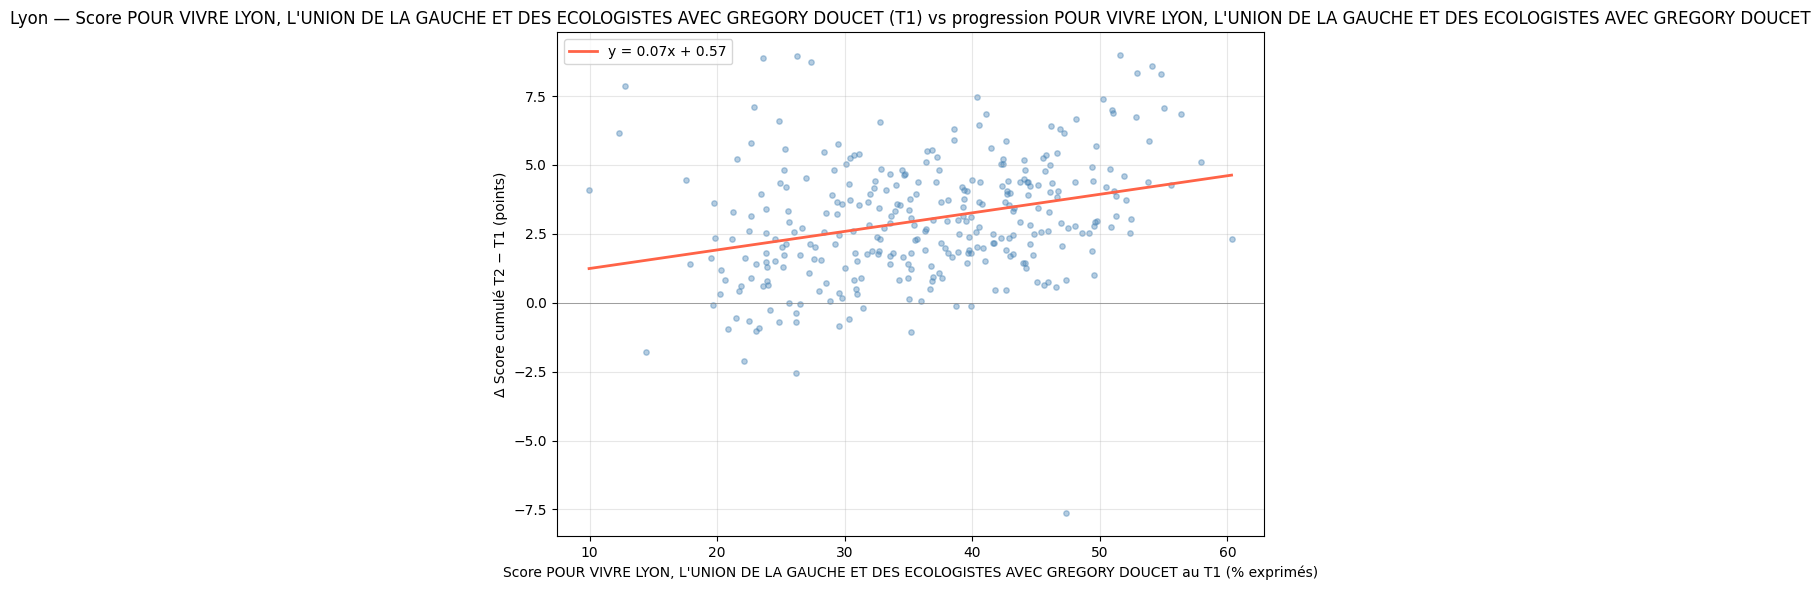

Lyon : 312 bureaux de vote retenus


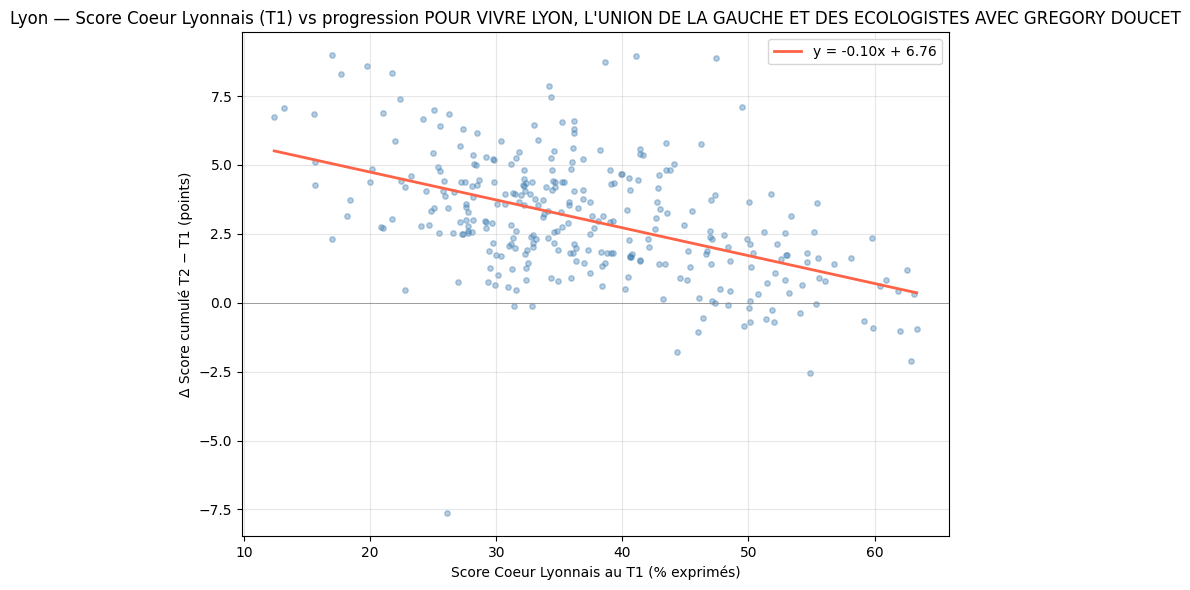

In [32]:

df_lyon = analyse_transfert(t1, t2, "Lyon", "69", "69388","Faire Mieux Pour Lyon - La France Insoumise", ["Faire Mieux Pour Lyon - La France Insoumise", "POUR VIVRE LYON, L'UNION DE LA GAUCHE ET DES ECOLOGISTES AVEC GREGORY DOUCET"], ["POUR VIVRE LYON, L'UNION DE LA GAUCHE ET DES ECOLOGISTES AVEC GREGORY DOUCET"])


df_lyon = analyse_transfert(t1, t2, "Lyon", "69", "69388","POUR VIVRE LYON, L'UNION DE LA GAUCHE ET DES ECOLOGISTES AVEC GREGORY DOUCET", ["Faire Mieux Pour Lyon - La France Insoumise", "POUR VIVRE LYON, L'UNION DE LA GAUCHE ET DES ECOLOGISTES AVEC GREGORY DOUCET"], ["POUR VIVRE LYON, L'UNION DE LA GAUCHE ET DES ECOLOGISTES AVEC GREGORY DOUCET"])


df_lyon = analyse_transfert(t1, t2, "Lyon", "69", "69388","Coeur Lyonnais", ["Faire Mieux Pour Lyon - La France Insoumise", "POUR VIVRE LYON, L'UNION DE LA GAUCHE ET DES ECOLOGISTES AVEC GREGORY DOUCET"], ["POUR VIVRE LYON, L'UNION DE LA GAUCHE ET DES ECOLOGISTES AVEC GREGORY DOUCET"])

Paris : 902 bureaux de vote retenus


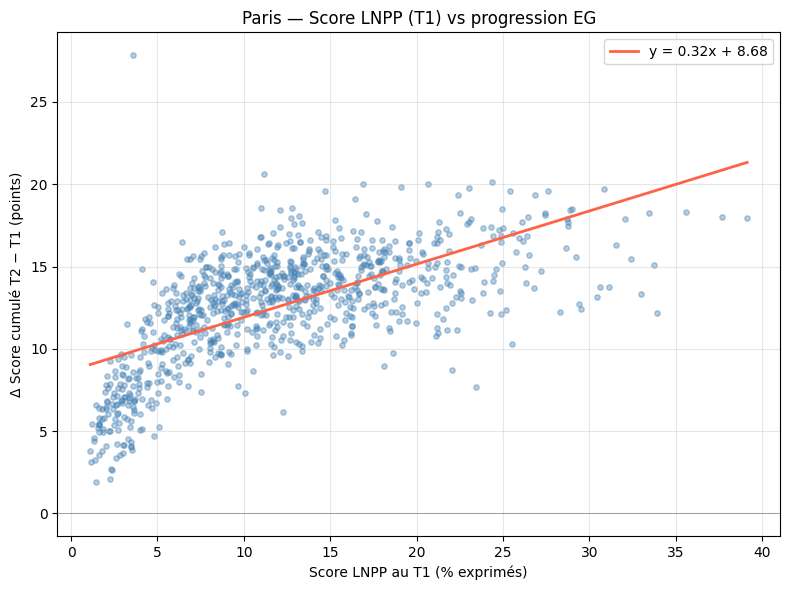

Paris : 902 bureaux de vote retenus


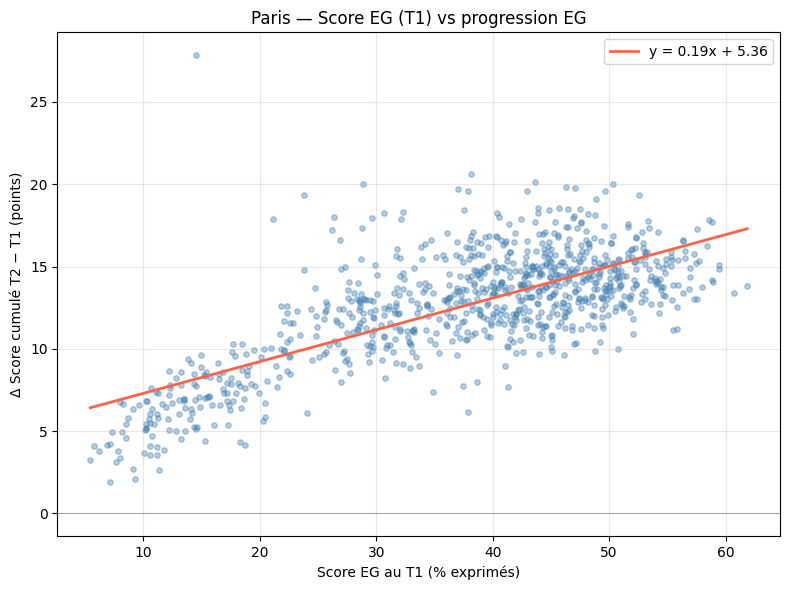

Paris : 902 bureaux de vote retenus


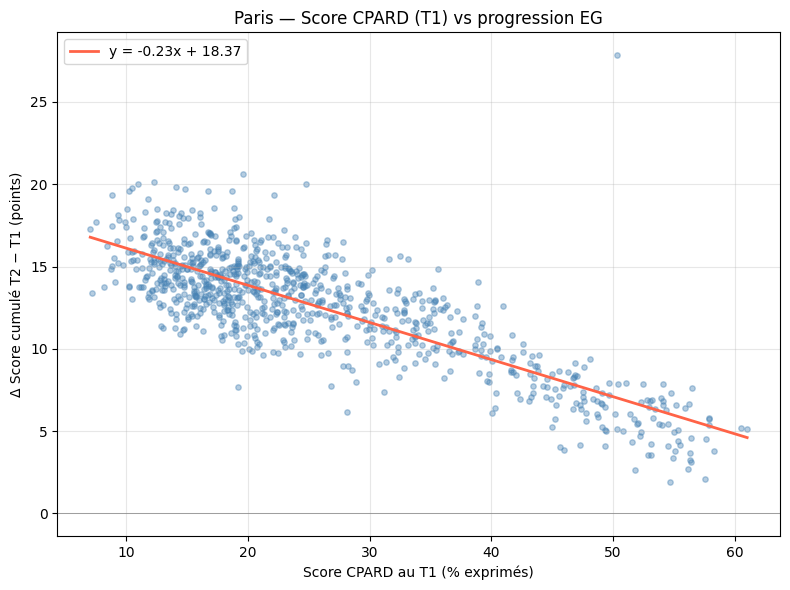

Paris : 902 bureaux de vote retenus


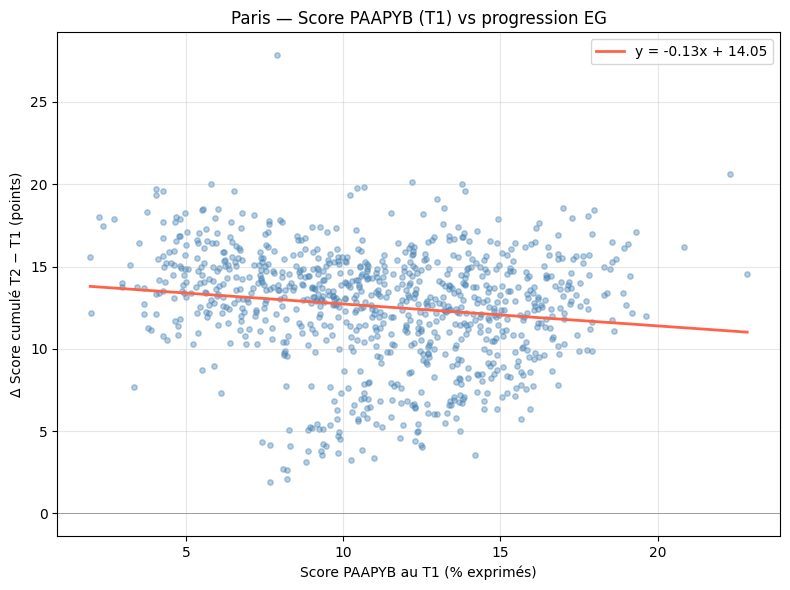

Paris : 902 bureaux de vote retenus


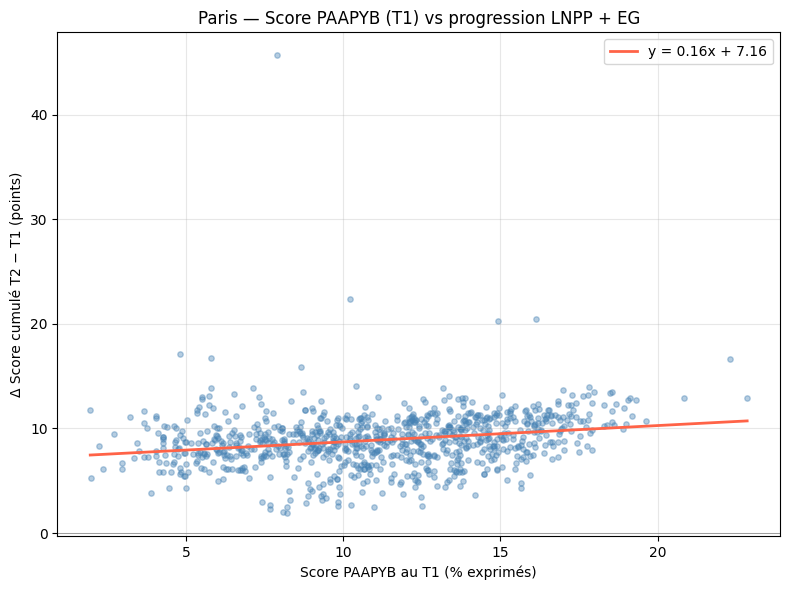

Paris : 902 bureaux de vote retenus


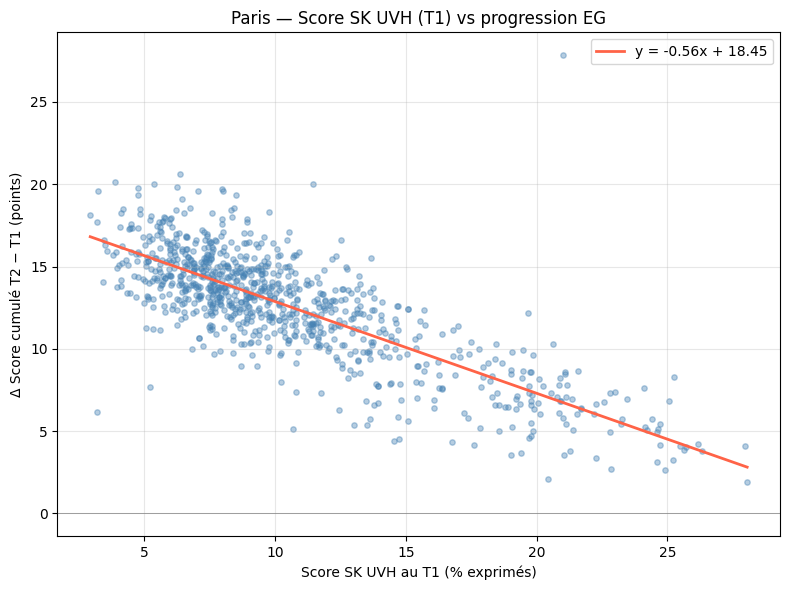

Paris : 902 bureaux de vote retenus


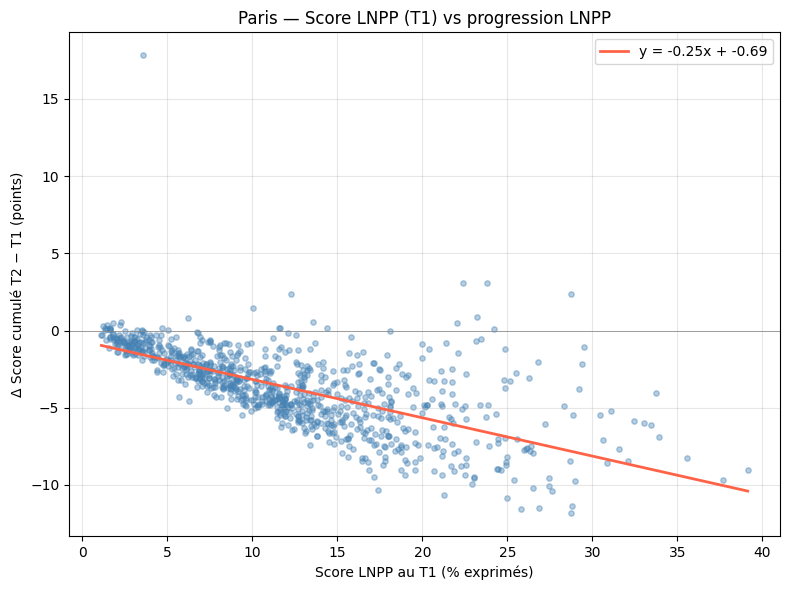

Paris : 902 bureaux de vote retenus


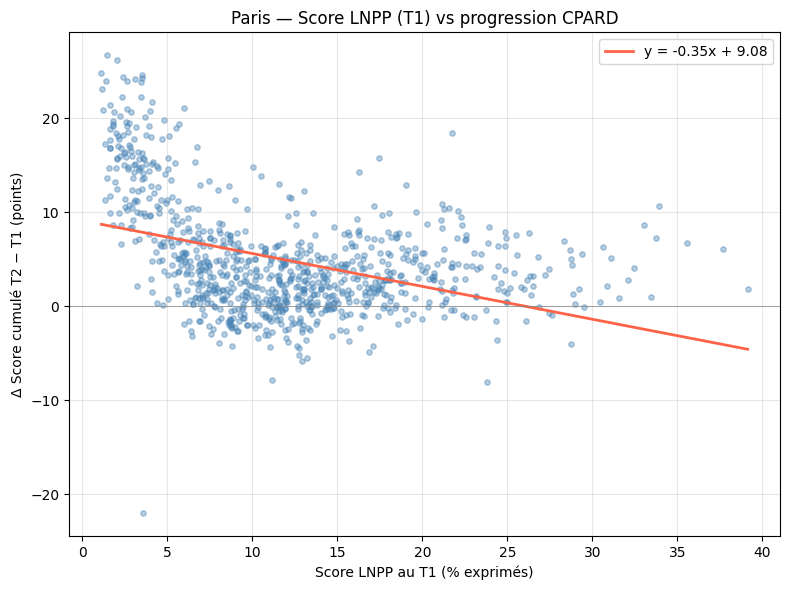

Paris : 902 bureaux de vote retenus


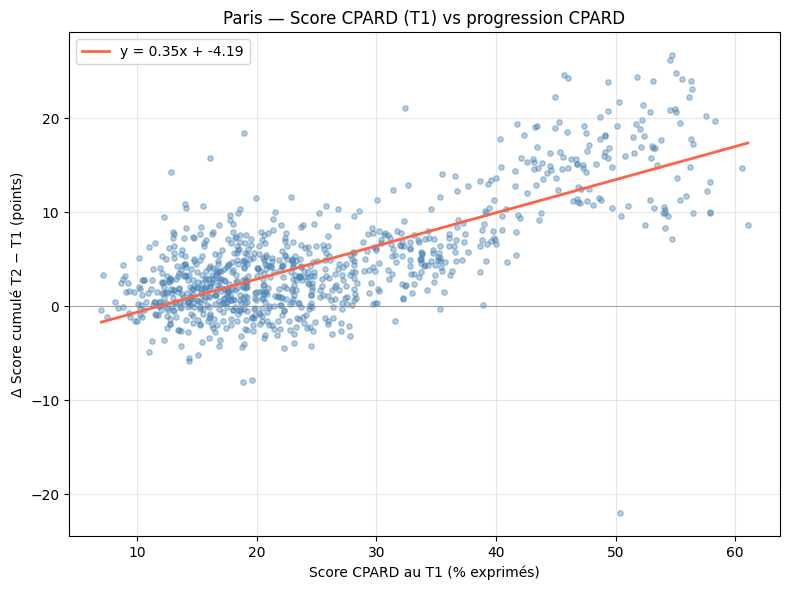

Paris : 902 bureaux de vote retenus


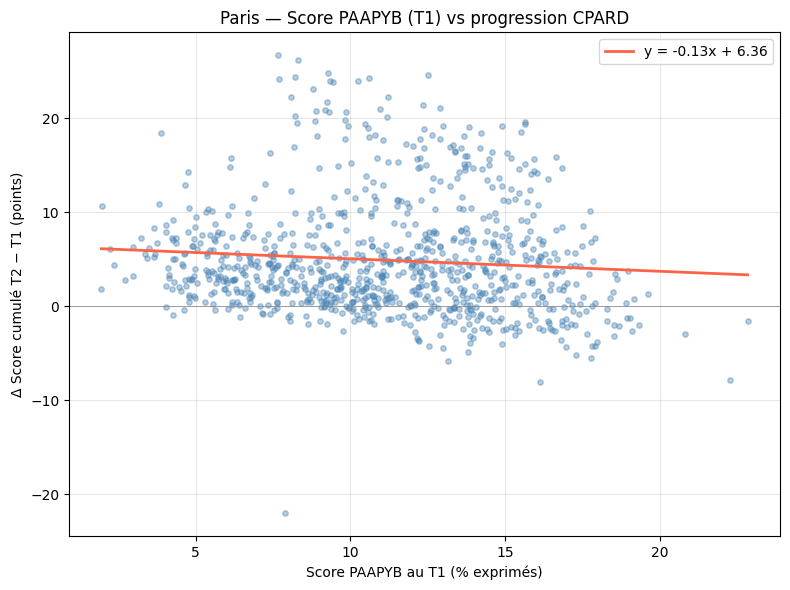

Paris : 902 bureaux de vote retenus


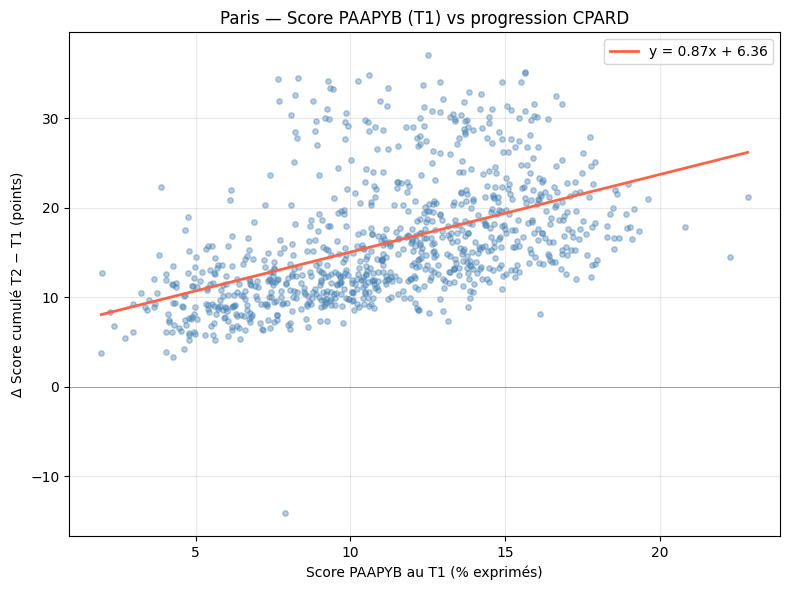

Paris : 902 bureaux de vote retenus


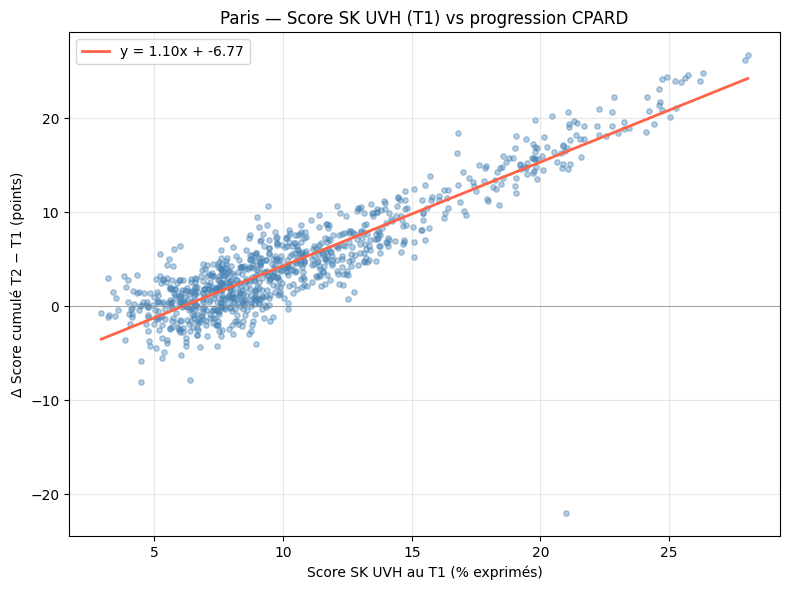

In [20]:

df_lyon = analyse_transfert(t1, t2, "Paris", "75", "75056","LNPP", ["EG"], ["EG"])


df_lyon = analyse_transfert(t1, t2, "Paris", "75", "75056","EG", ["EG"], ["EG"])


df_lyon = analyse_transfert(t1, t2,"Paris", "75", "75056","CPARD", ["EG"], ["EG"])


df_lyon = analyse_transfert(t1, t2, "Paris", "75", "75056","PAAPYB", ["EG"], ["EG"])
df_lyon = analyse_transfert(t1, t2, "Paris", "75", "75056","PAAPYB", ["LNPP","EG"], ["LNPP","EG"])


df_lyon = analyse_transfert(t1, t2, "Paris", "75", "75056","SK UVH", ["EG"], ["EG"])


df_lyon = analyse_transfert(t1, t2, "Paris", "75", "75056","LNPP", ["LNPP"], ["LNPP"])
df_lyon = analyse_transfert(t1, t2, "Paris", "75", "75056","LNPP", ["PAAPYB", "CPARD"], ["CPARD"])
df_lyon = analyse_transfert(t1, t2, "Paris", "75", "75056","CPARD", ["PAAPYB", "CPARD"], ["CPARD"])

df_lyon = analyse_transfert(t1, t2, "Paris", "75", "75056","PAAPYB", ["PAAPYB", "CPARD"], ["CPARD"])
df_lyon = analyse_transfert(t1, t2, "Paris", "75", "75056","PAAPYB", ["CPARD"], ["CPARD"])

df_lyon = analyse_transfert(t1, t2, "Paris", "75", "75056","SK UVH", ["PAAPYB", "CPARD"], ["CPARD"])



In [89]:
def analyse_delta_vs_delta(t1, t2, ville, code_dept, code_commune,
                           labels_x_t1, labels_x_t2,
                           labels_y_t1, labels_y_t2,
                           nom_x="Liste X", nom_y="Liste Y",
                           title="Δ Score X vs Δ Score Y",
                           part_min=0):
    """
    Scatter plot : Δ score liste X (axe X) vs Δ score liste Y (axe Y) entre T1 et T2.
    """
    
    def extract(df, labels):
        mask = (df["Code département"] == code_dept) & (df["Code commune"] == code_commune)
        toul = df[mask].copy()
        if toul.empty:
            mask = df["Libellé commune"].str.contains(ville, case=False, na=False)
            toul = df[mask].copy()
        
        toul["% Votants"] = toul["% Votants"].str.replace(",", ".").str.replace("%", "").astype(float)
        
        labels_upper = [l.upper().strip() for l in labels]
        
        scores = []
        for _, row in toul.iterrows():
            total = 0.0
            found = []
            for i in range(1, 14):
                col_label = f"Libellé abrégé de liste {i}"
                col_voix_pct = f"% Voix/inscrits {i}"
                if col_label in row.index and pd.notna(row[col_label]):
                    label = str(row[col_label]).upper().strip()
                    if label in labels_upper:
                        val = row[col_voix_pct]
                        if pd.notna(val) and val != "":
                            total += float(str(val).replace(",", ".").replace("%", ""))
                            found.append(label)
            scores.append(total if found else None)
        
        toul["Score"] = scores
        return toul[["Code BV", "% Votants", "Score"]].copy()
    
    # Extraire les 4 scores
    x_t1 = extract(t1, labels_x_t1).rename(columns={"Score": "Score_X_T1", "% Votants": "Part_T1"})
    x_t2 = extract(t2, labels_x_t2).rename(columns={"Score": "Score_X_T2", "% Votants": "Part_T2"})
    y_t1 = extract(t1, labels_y_t1).rename(columns={"Score": "Score_Y_T1"}).drop(columns=["% Votants"])
    y_t2 = extract(t2, labels_y_t2).rename(columns={"Score": "Score_Y_T2"}).drop(columns=["% Votants"])
    
    merged = x_t1[["Code BV", "Part_T1", "Score_X_T1"]]
    merged = merged.merge(x_t2[["Code BV", "Part_T2", "Score_X_T2"]], on="Code BV", how="outer")
    merged = merged.merge(y_t1[["Code BV", "Score_Y_T1"]], on="Code BV", how="outer")
    merged = merged.merge(y_t2[["Code BV", "Score_Y_T2"]], on="Code BV", how="outer")
    merged = merged.sort_values("Code BV").reset_index(drop=True)
    
    # Filtrage
    temp = merged.dropna(subset=["Score_X_T1", "Score_X_T2", "Score_Y_T1", "Score_Y_T2", "Part_T1", "Part_T2"])
    temp = temp[(temp["Part_T1"] >= part_min) & (temp["Part_T2"] >= part_min)]
    
    x = -(temp["Score_X_T2"] - temp["Score_X_T1"]).values
    y = (temp["Score_Y_T2"] - temp["Score_Y_T1"]).values
    
    print(f"{ville} : {len(x)} bureaux de vote retenus")
    
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(x, y, alpha=0.7, s=15, color="black", linewidths=0)
    
    if len(x) > 1:
        coeffs = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, np.polyval(coeffs, x_line), color="tomato", linewidth=2,
                label=f"y = {coeffs[0]:.2f}x + {coeffs[1]:.2f}")
        ax.legend()
    
    ax.set_xlabel(f"Baisse du Score {nom_x} (T2 − T1, points)")
    ax.set_ylabel(f"Augmentation du Score {nom_y} (T1 − T2, points)")
    ax.set_title(f"{ville} — {title}")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return merged

Marseille : 0 bureaux de vote retenus


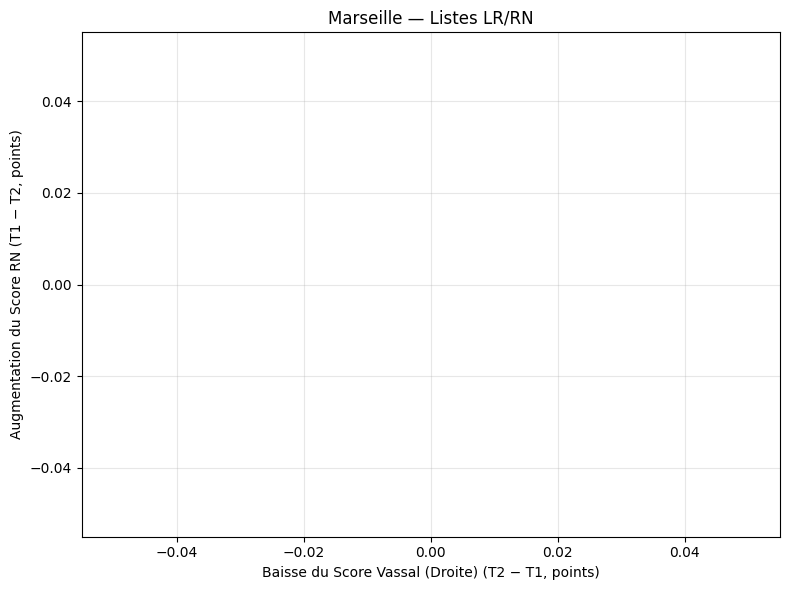

Marseille : 497 bureaux de vote retenus


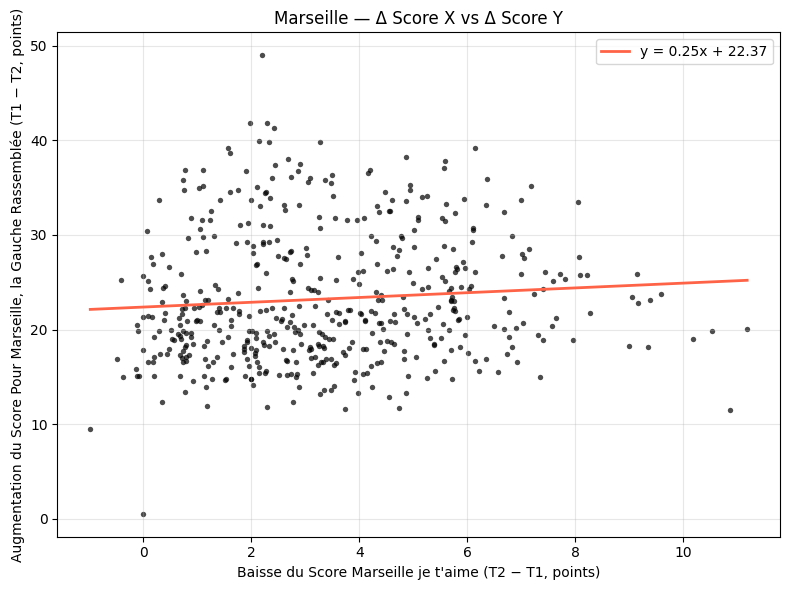

In [ ]:
df_marseille = analyse_delta_vs_delta(t1, t2, "Marseille", "13", "13055",
                          ["MARSEILLE JE T'AIME"], ["MARSEILLE JE T'AIME"],
                          ["MARSEILLE EN ORDRE"], ["MARSEILLE EN ORDRE"],
                          nom_x="Vassal (Droite)", nom_y="RN", 
                          title="Listes LR/RN")

df_marseille = analyse_delta_vs_delta(t1, t2, "Marseille", "13", "13055",
                          ["MARSEILLE JE T'AIME"], ["MARSEILLE JE T'AIME"],
                          ["POUR MARSEILLE, LA GdAUCHE RASSEMBLES","MARSEILLE FIÈRE ET POPULAIRE"], ["POUR MARSEILLE, LA GAUCHE RASSEMBLES"],
                          nom_x="Marseille je t'aime", nom_y="Pour Marseille, la Gauche Rassemblée")

Nîmes : 86 bureaux de vote retenus


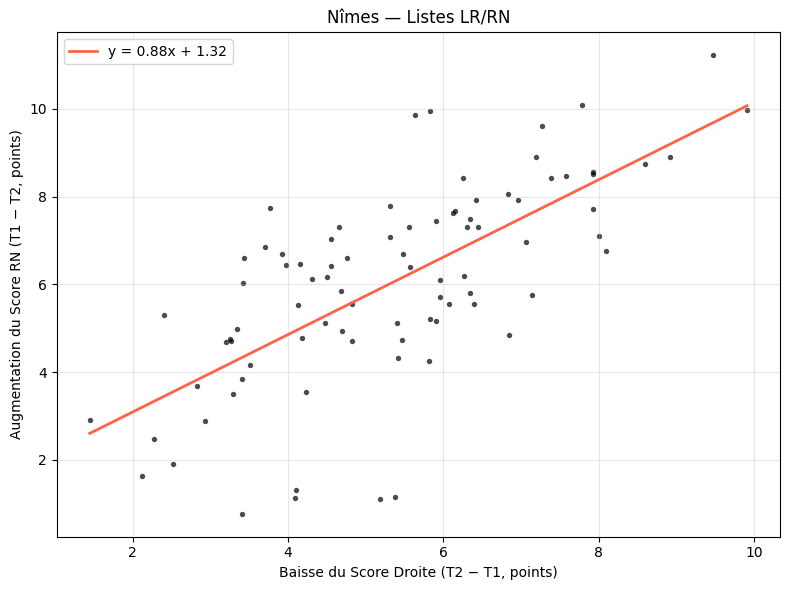

In [104]:
_ = analyse_delta_vs_delta(t1, t2, "Nîmes", "30", "30189",
                          ["L'Avenir Nîmois", "TOUT NÎMES"], ["NÎMES PAR-DESSUS TOUT"],
                          ["FIERS D'ÊTRE NÎMOIS !"], ["FIERS D'ÊTRE NÎMOIS !"],
                          nom_x="Droite", nom_y="RN", 
                          title="Listes LR/RN")

Saint-Etienne : 101 bureaux de vote retenus


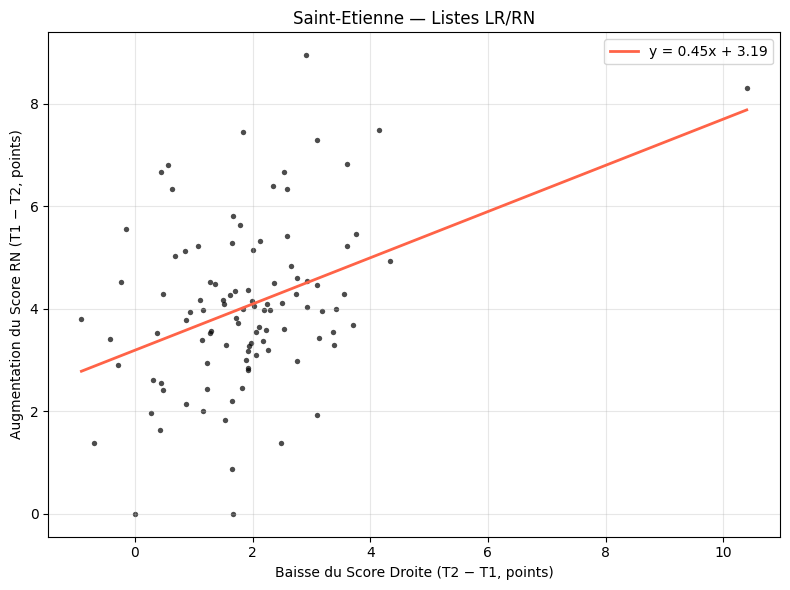

In [108]:
_ = analyse_delta_vs_delta(t1, t2, "Saint-Etienne", "42", "42218",
                          ["Ensemble pour Saint-Etienne", "GRANDIR, VIVRE, TRANSMETTRE"], ["Ensemble pour Saint-Etienne"],
                          ["RETROUVER SAINTÉ !"], ["RETROUVER SAINTÉ !"],
                          nom_x="Droite", nom_y="RN", 
                          title="Listes LR/RN")

In [ ]:
# Electorat LR/RN porosité.
# Clermont 